# Week 7: Functional Connectivity  

This week, we turn to a very different approach to analysing fMRI data—functional connectivity. Over the past decade, this method has become central to understanding brain organisation. Instead of modelling task-related events from an experimental design, we examine correlations between BOLD signals in different brain regions.  

Such data are often acquired during “resting-state” scans, when participants are not engaged in any specific task. We will begin with **seed-based functional connectivity**, where the BOLD time course from one region is correlated with the rest of the brain. Next, we will extend this to **whole-brain connectivity**, calculating correlations across all regions.  

Building on this, we will learn how to represent connectivity results as **network graphs**, which allow us to visualise and quantify brain networks. We will also explore **independent component analysis (ICA)** as an alternative way to identify large-scale functional networks. Finally, we will apply a **machine learning approach** to predict age from functional connectivity measures.  

By the end of this tutorial, you should understand the principles of functional connectivity analysis and be able to perform a basic analysis of connectivity data in Python.  

**What you’ll learn**  
- How to run a seed-based functional connectivity analysis  
- How to perform independent component analysis (ICA)  
- How to create and interpret network graphs  
- How to calculate graph-theoretical measures of connectivity  
- How to apply machine learning to predict external variables from connectivity data  

**Expected time to complete**: 4–6 hours  

**Attribution**:
- Revised by Joe Bathelt (2025)
- Revised by Joe Bathelt (2024)
- Originally developed by Joe Bathelt (2023)


### 1. Seed-based correlation analysis  

In seed-based correlation analysis (SCA), a single region of interest (ROI) is selected to serve as the *seed* for computing functional connectivity. The resulting map shows which regions have the most similar BOLD time course, indicating that they are likely part of the same functional network.  

The seed region can be defined in different ways: it may be a single voxel, an anatomically defined region, or a functionally defined region derived from a task or a meta-analysis.  

Before running the analysis, we first need to load some functional imaging data. In this example, we assume that the data have already been pre-processed (e.g., with **fMRIPrep**). This means you should have:  
- a fully preprocessed functional data file, and  
- a file containing confound variables derived from the functional data.  

In [7]:
from nilearn import datasets

# Fetch a sample developmental fMRI dataset with 1 subject
dataset = datasets.fetch_development_fmri(n_subjects=1)

# Get the preprocessed functional image (BOLD time series)
func_filename = dataset.func[0]

# Get the corresponding confounds file (motion, physiological noise, etc.)
confound_filename = dataset.confounds[0]

# Define the repetition time (TR) in seconds
TR = 2.0

Now we need to define a seed region. In this example, we will focus on the posterior cingulate cortex (PCC), a key hub of the default mode network. We will use coordinates for this region taken from a published study as the seed location.

In [8]:
# Define MNI coordinates for the posterior cingulate cortex (PCC)
pcc_coords = [(0, -52, 18)]

Now we can calculate the correlation between the seed region and the rest of the brain. For this, we will use **Nilearn**, which follows an object-oriented workflow: first, you create an object and specify its parameters; then, you apply it to your data to perform the analysis.

#### 1.1 Extracting the seed time series  

Next, we will extract the BOLD time series from our seed region. Using the MNI coordinates of the PCC defined above, we compute the average signal within a sphere of 8 mm radius around these coordinates.  

To make the signal easier to interpret, we standardise it by converting it to z-scores. Finally, we apply band-pass filtering to remove low-frequency drifts and high-frequency noise, keeping only the frequency range relevant for functional connectivity analysis.  

In [9]:
from nilearn.maskers import NiftiSpheresMasker

# Setting the parameters of a NiftiSpheresMasker object
seed_masker = NiftiSpheresMasker(
    pcc_coords,
    radius=4, # here we define a sphere around the coordinates, in this case with an 4mm radius
    detrend=True, # we detrend the data
    standardize="zscore_sample", # we standardize the data to z-scores
    low_pass=0.1, # we apply a low-pass filter with a cutoff of 0.1 Hz
    high_pass=0.01, # we apply a high-pass filter with a cutoff of 0.01 Hz
    t_r=TR, # we set the repetition time to 2s
    memory="nilearn_cache",
    memory_level=1,
    verbose=0,
)

# Applying the NiftiSphereMasker to the functional data
seed_time_series = seed_masker.fit_transform(
    func_filename
)

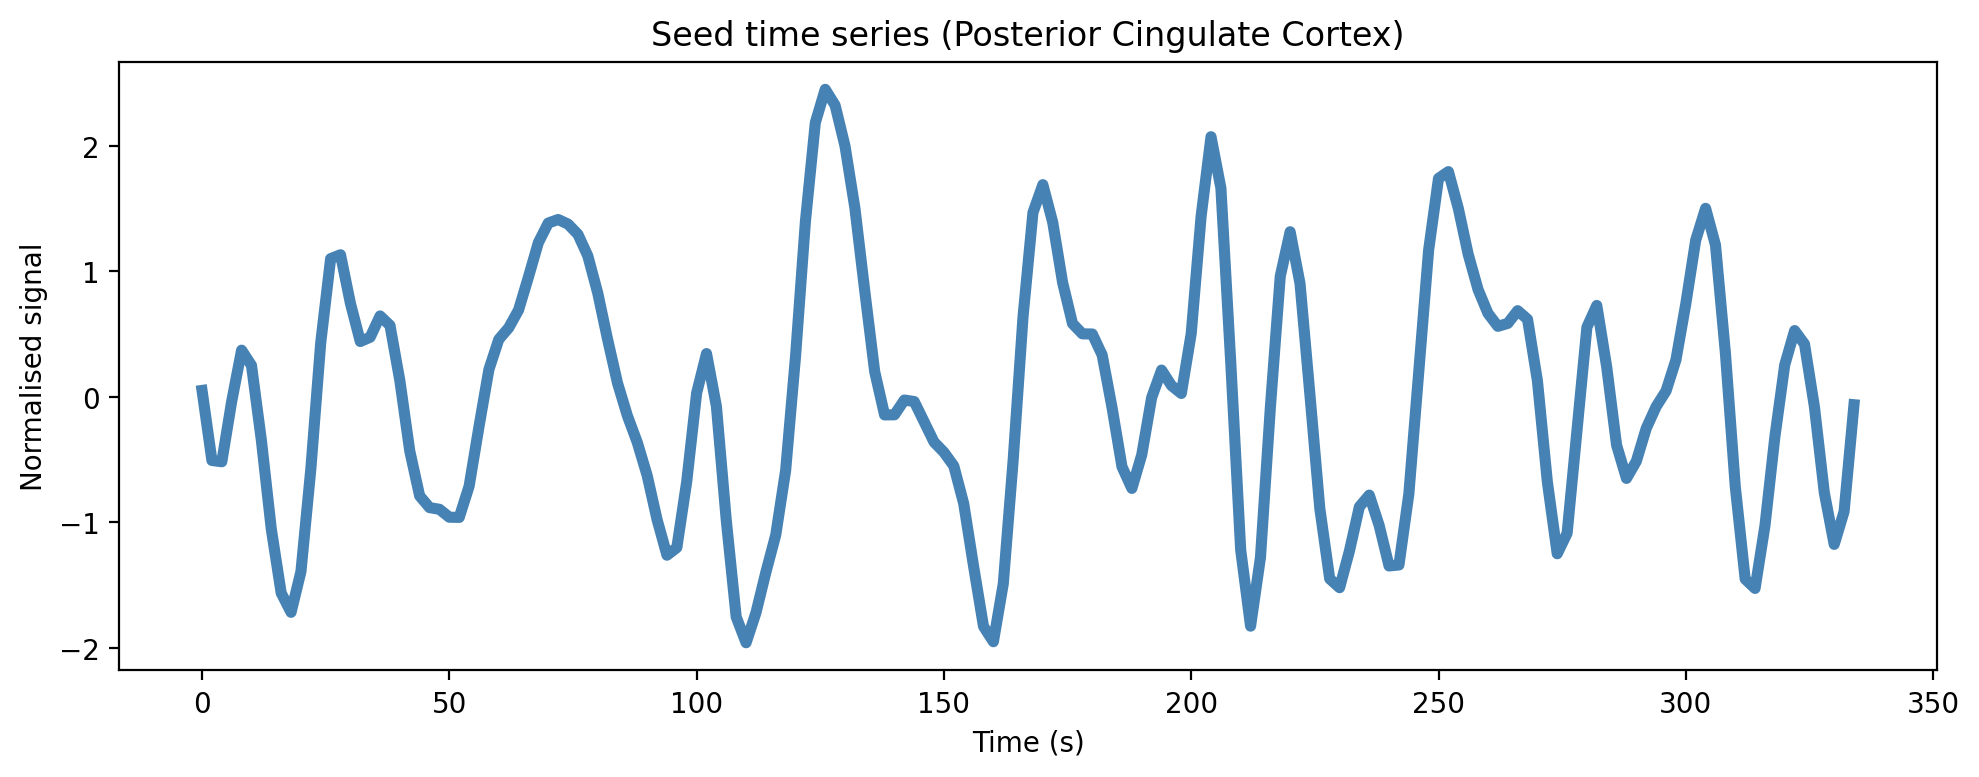

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Create a time axis in seconds based on TR and the number of time points
time = TR * np.arange(len(seed_time_series))

# Plot the seed time series
plt.figure(figsize=(10, 4))
plt.plot(time, seed_time_series, linewidth=4, color="steelblue")
plt.title("Seed time series (Posterior Cingulate Cortex)")
plt.xlabel("Time (s)")
plt.ylabel("Normalised signal")
plt.tight_layout()
plt.show()

<div class='alert alert-warning'>  
<b>ToDo</b> (not graded):  

Oh no — we forgot to include the confounds!
Use the Nilearn documentation to update the correlation analysis so that confounds are included.  

💡 **Tip**: You can access documentation directly in the notebook by calling `?function_name`, e.g. `?NiftiSpheresMasker`. You may need to scroll down to see all arguments. Alternatively, check the online docs: [NiftiSpheresMasker — Nilearn](https://nilearn.github.io/modules/generated/nilearn.input_data.NiftiSpheresMasker.html).  

👉 Your task:  

- Call the function again  
- Add the confounds to the calculation  
- Save the results in a variable called `confound_regressed_ts`  

</div>  

<details open>
  <summary>Solution (click to expand)</summary>

```python
from nilearn.input_data import NiftiSpheresMasker

# Define the masker with confound regression
masker = NiftiSpheresMasker(
    seeds=pcc_coords,
    radius=8,
    detrend=True,
    standardize="zscore",
    low_pass=0.1,
    high_pass=0.01,
    t_r=TR
)

# Extract time series while regressing out confounds
confound_regressed_ts = masker.fit_transform(
    func_filename, 
    confounds=confound_filename
)
```

</details>



In [11]:
# YOUR CODE HERE
from nilearn.input_data import NiftiSpheresMasker

# Define the masker with confound regression
masker = NiftiSpheresMasker(
    seeds=pcc_coords,
    radius=8,
    detrend=True,
    standardize="zscore",
    low_pass=0.1,
    high_pass=0.01,
    t_r=TR
)

# Extract time series while regressing out confounds
confound_regressed_ts = masker.fit_transform(
    func_filename, 
    confounds=confound_filename
)
# raise NotImplementedError()

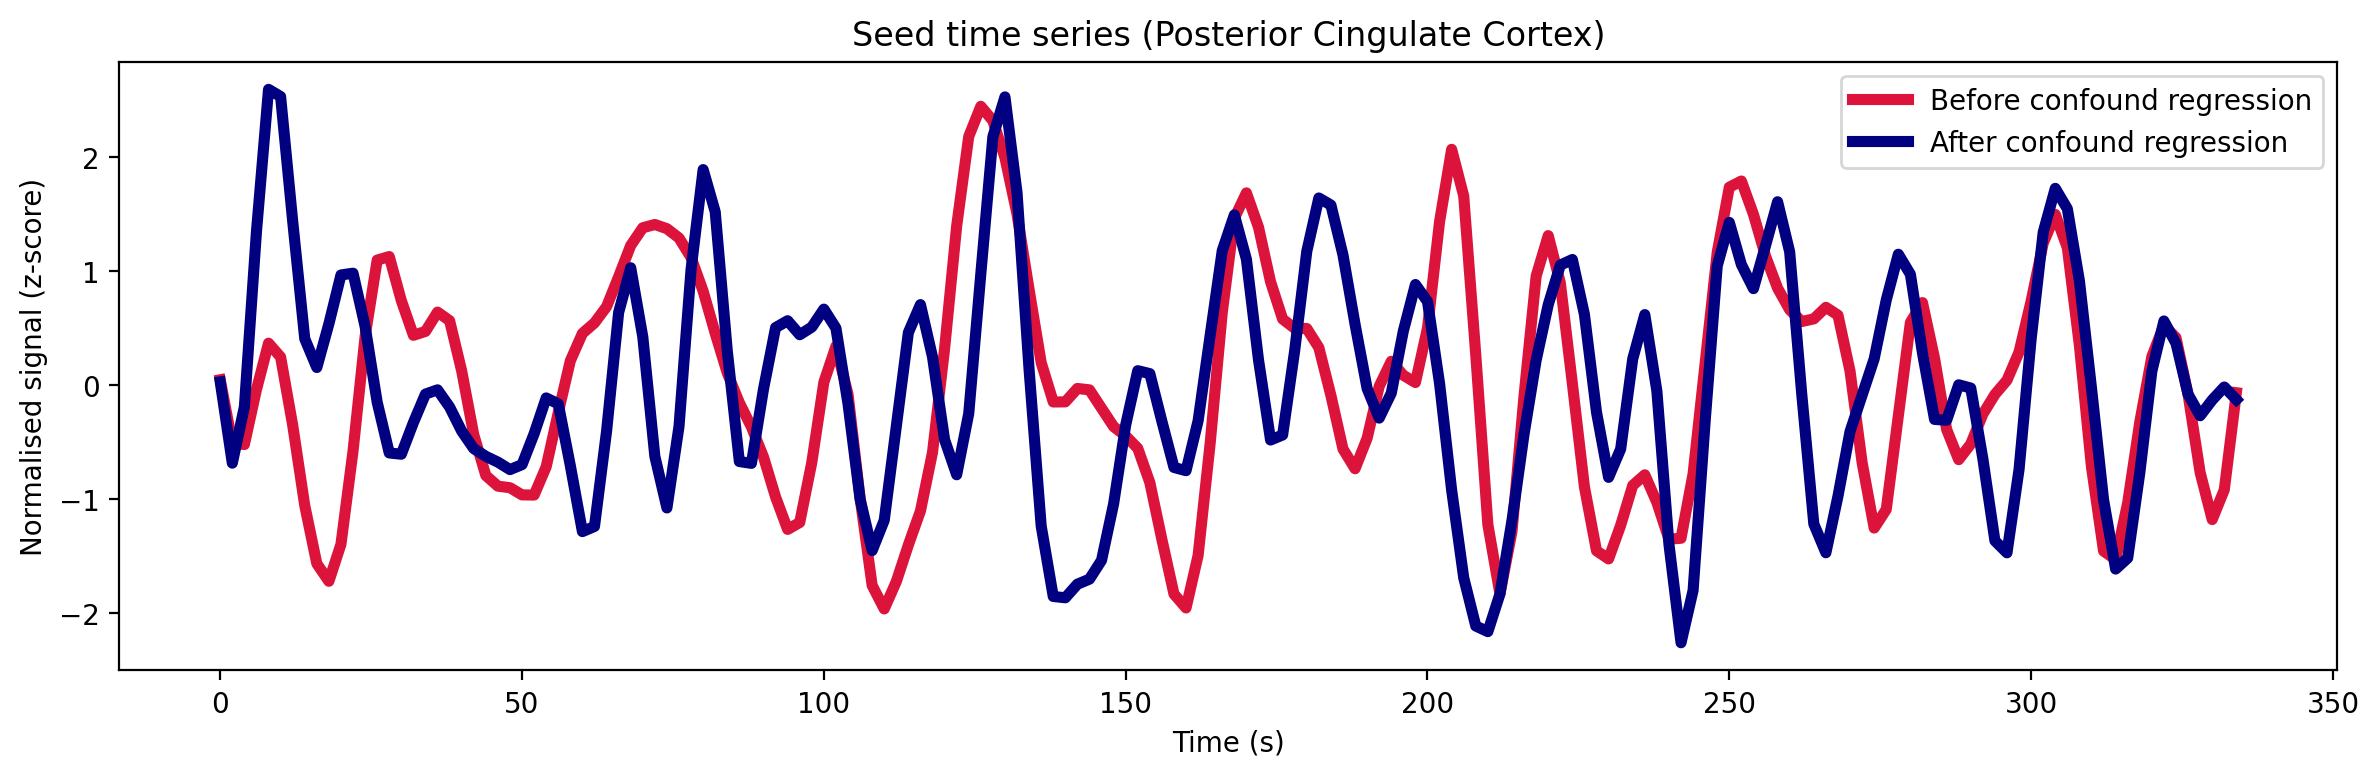

In [12]:
# Create a time axis in seconds
time = TR * np.arange(len(seed_time_series))

# Plot original vs. confound-regressed time series
plt.figure(figsize=(12, 4))
plt.plot(time, seed_time_series, linewidth=4, color="crimson", label="Before confound regression")
plt.plot(time, confound_regressed_ts, linewidth=4, color="navy", label="After confound regression")

plt.title("Seed time series (Posterior Cingulate Cortex)")
plt.xlabel("Time (s)")
plt.ylabel("Normalised signal (z-score)")
plt.legend()
plt.tight_layout()
plt.show()

#### 1.2 Extracting whole-brain time series  

In seed-based connectivity analysis, our goal is to determine how the seed region is correlated with the rest of the brain. To achieve this, we compute the correlation between the seed’s time series and the time series of all other voxels across the brain.  

This produces a whole-brain map of correlation values, highlighting regions that are functionally connected to the seed. Since we already have the seed time series, our next step is to extract the time series from the entire brain.  

In [13]:
from nilearn.input_data import NiftiMasker

# Define a brain masker to extract whole-brain time series
brain_masker = NiftiMasker(
    smoothing_fwhm=6,             # Apply spatial smoothing (6 mm FWHM)
    detrend=True,                 # Remove linear trends
    standardize="zscore_sample",  # Standardise each voxel’s time series (z-scores)
    low_pass=0.1,                 # Apply temporal band-pass filtering
    high_pass=0.01,
    t_r=TR,                       # Repetition time
    memory="nilearn_cache",       
    memory_level=1,
    verbose=0
)

# Extract whole-brain time series while regressing out confounds
brain_time_series = brain_masker.fit_transform(
    func_filename,
    confounds=confound_filename
)

Great — we now have the time series for all voxels in the brain.  
To get an intuition for the data, let’s plot the seed region’s time series alongside the time series from a few randomly selected voxels and compare how similar they look.  

<div class='alert alert-warning'>  
<b>ToDo</b> (1 point): Plot the time series. <br><br>  

1. Extract the time series of voxels at index **10** and **100**. <br>  
2. Plot the time series of:  
   - the seed region (after confound regression) in **red**,  
   - voxel 10 in **blue**,  
   - voxel 100 in **green**. <br>  
3. Add clear axis labels, a title, and a legend.  
    
💡 This will be graded manually (no feedback cell).
</div>  

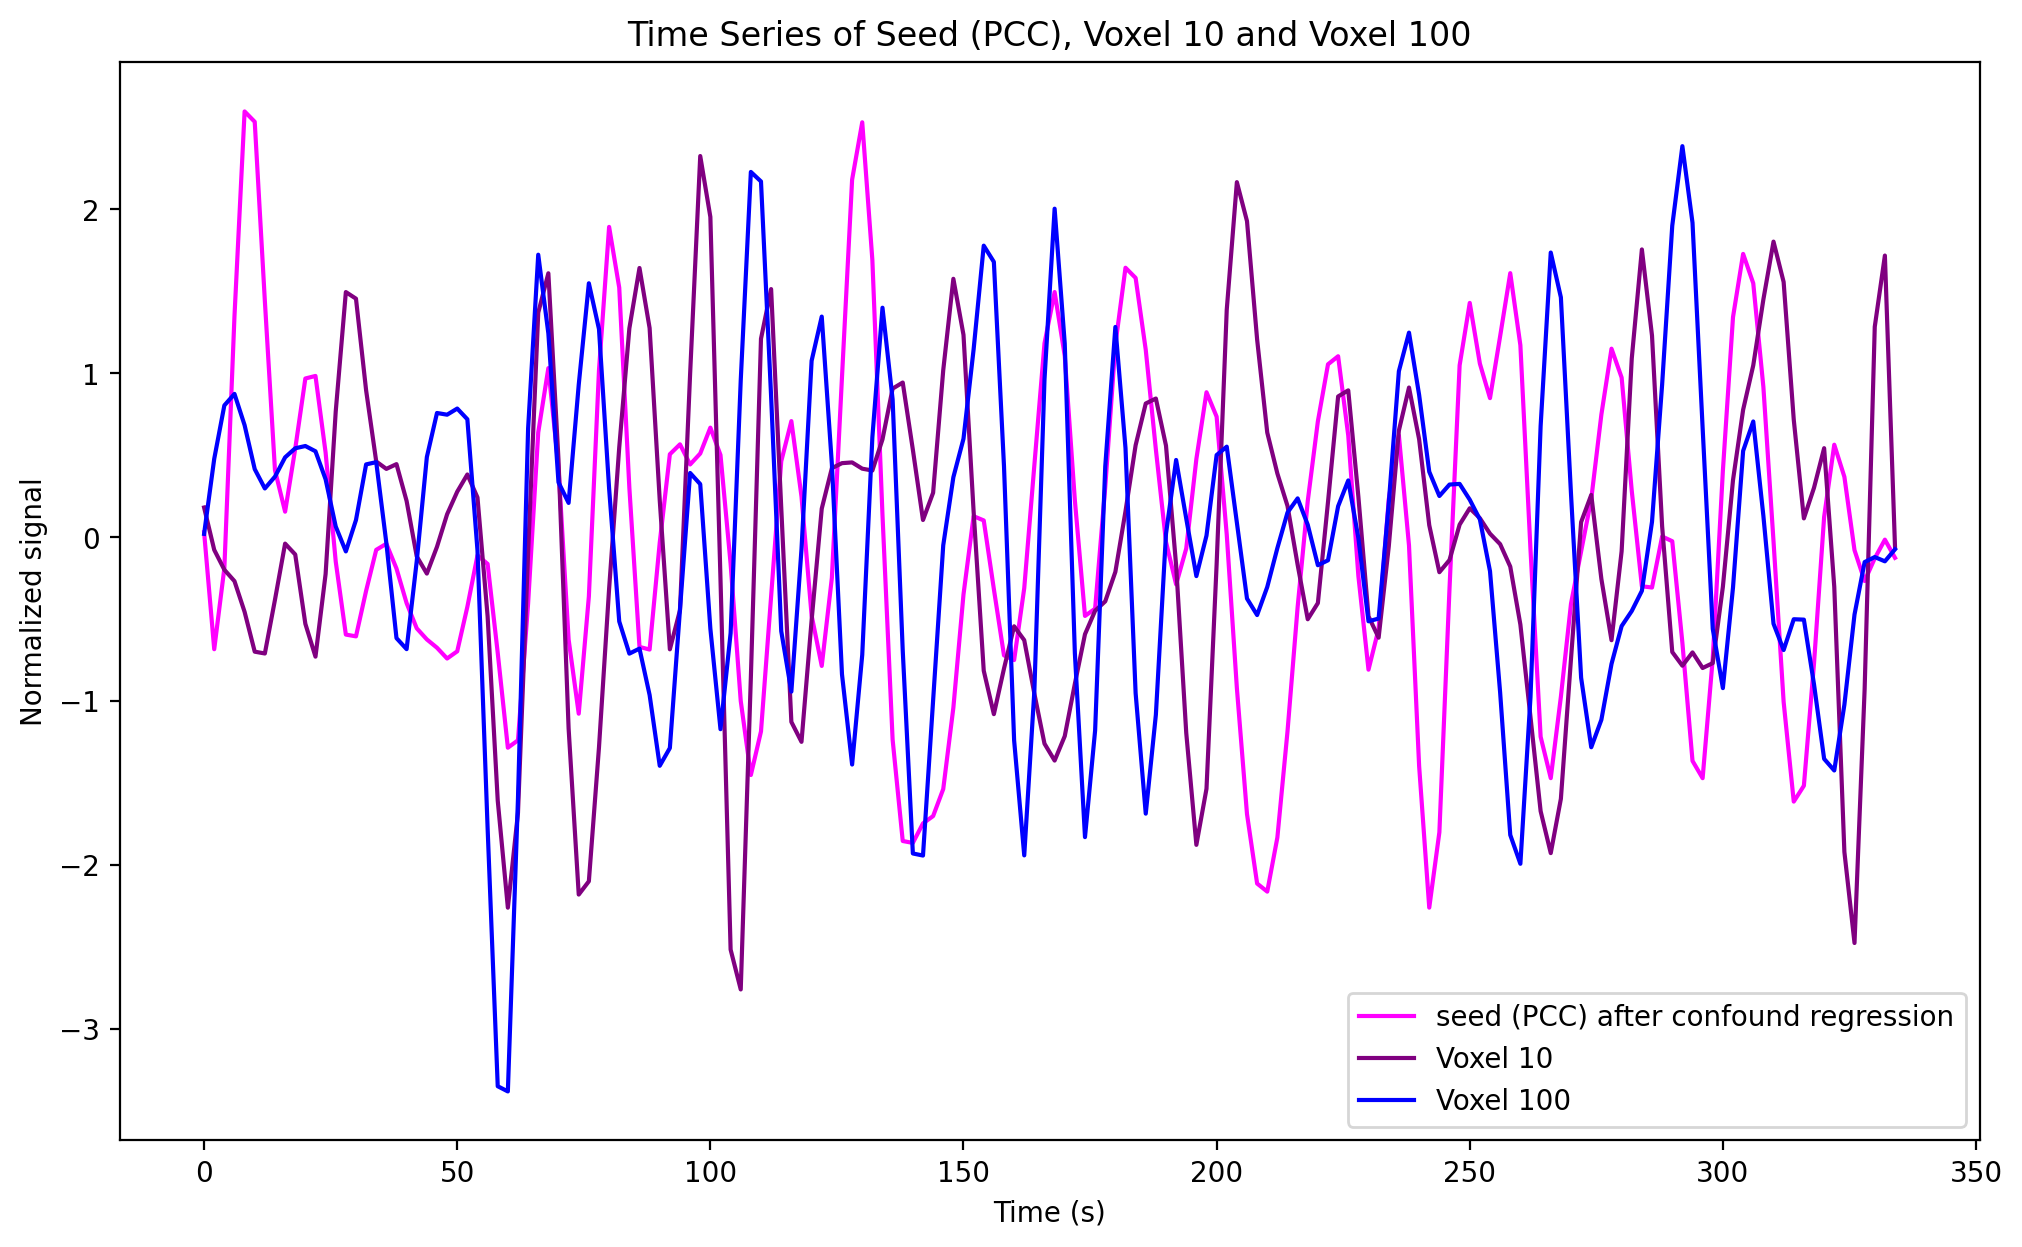

In [14]:
# YOUR CODE HERE

# extracting time series of voxels at index 10 and 100
voxel_10_time_series = brain_time_series[:, 9]
voxel_100_time_series = brain_time_series[:, 99]

# time series plot 
time = TR*np.arange(0, len(confound_regressed_ts))
plt.plot(time, confound_regressed_ts, 'magenta', label='seed (PCC) after confound regression')
plt.plot(time, voxel_10_time_series, 'purple', label='Voxel 10')
plt.plot(time, voxel_100_time_series, 'blue', label='Voxel 100')
plt.title('Time Series of Seed (PCC), Voxel 10 and Voxel 100')
plt.ylabel('Normalized signal')
plt.xlabel('Time (s)')
plt.legend()

# raise NotImplementedError()

#### 1.3 Calculating the whole-brain correlation map  

Now we are ready to calculate the correlation between the seed region and all other voxels in the brain.  

One option would be to loop over every voxel and compute correlations individually, but this would be very inefficient. Instead, we can use matrix algebra to perform the calculation in one step. By taking the **dot product** of the seed time series with the time series of all voxels, we obtain a vector of correlation coefficients — one value per voxel — which forms our whole-brain correlation map.  

In [15]:
# Compute Pearson correlation between the seed time series and all voxels

# Flatten the seed time series (shape: n_timepoints,)
seed_ts = confound_regressed_ts.ravel()

# Z-score seed and voxel time series
seed_ts_z = (seed_ts - seed_ts.mean()) / seed_ts.std()
brain_ts_z = (brain_time_series - brain_time_series.mean(axis=0)) / brain_time_series.std(axis=0)

# Pearson correlation = dot product of z-scored signals / (n_timepoints - 1)
seed_to_voxel_correlations = np.dot(brain_ts_z.T, seed_ts_z) / (len(seed_ts) - 1)

We can reshape the resulting vector into a 3D image and plot it.

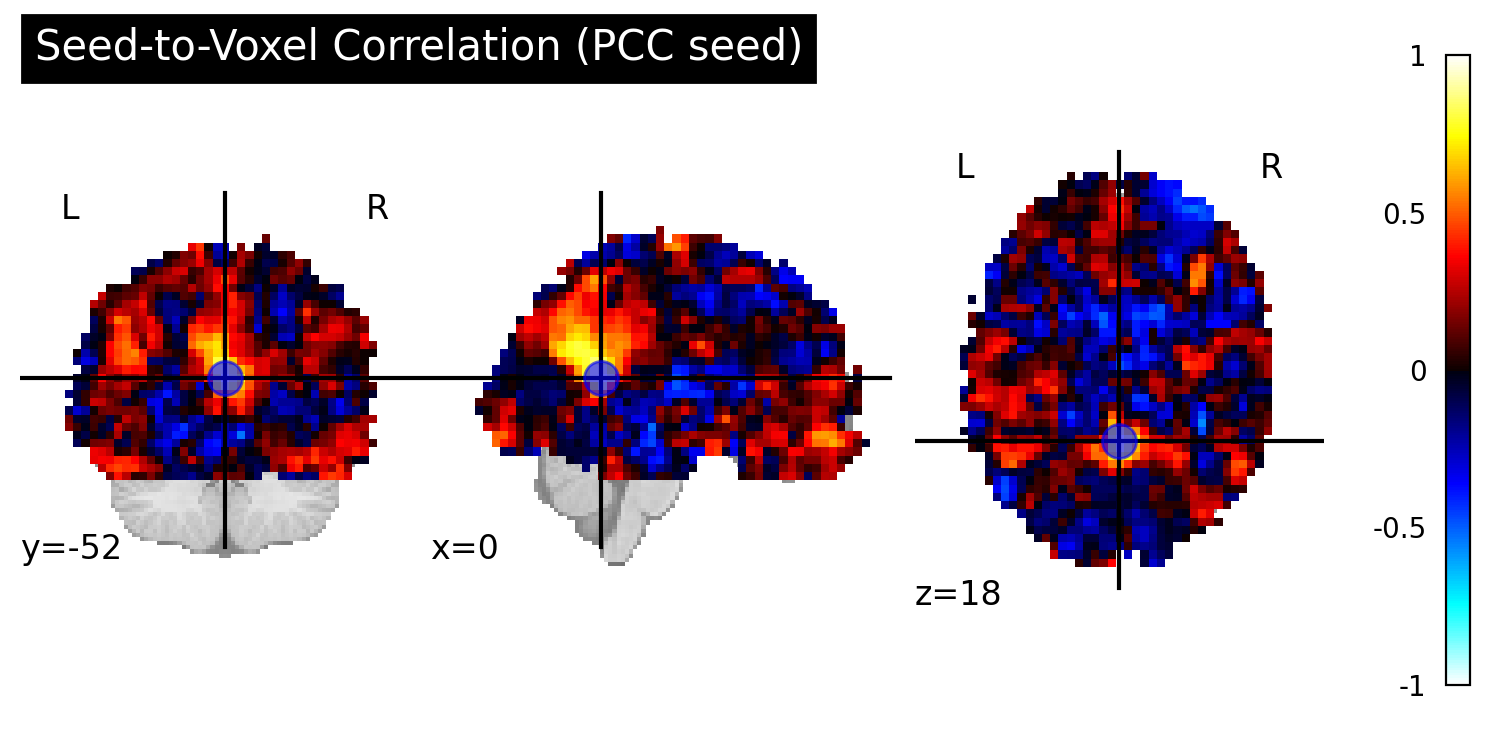

In [16]:
from nilearn import plotting

# Convert the 1D correlation vector back into a brain image
seed_to_voxel_correlations_img = brain_masker.inverse_transform(
    seed_to_voxel_correlations.T
)

# Plot the seed-to-voxel correlation map
display = plotting.plot_stat_map(
    seed_to_voxel_correlations_img,
    vmin=-1.0, vmax=1.0,              # Restrict to valid correlation range
    cut_coords=pcc_coords[0],         # Centre cuts on the seed coordinates
    title="Seed-to-Voxel Correlation (PCC seed)",
    cmap="cold_hot"                   # Highlight positive vs. negative correlations
)

# Add a marker for the seed location (PCC)
display.add_markers(
    marker_coords=pcc_coords,
    marker_color="blue",
    marker_size=150,
    alpha=0.6
)

<div class='alert alert-info'>
  <b>ToThink</b> (0 points): You may have noticed that some brain areas are not visible in the correlation map.  
  What might explain this? Jot down your ideas now and compare with the notes below at the end.
</div>

<details>
  <summary><b>Likely reason (click to expand)</b></summary>

The most likely reason is that that the  scans did not cover the whole brain (limited field of view). For instance, the researchers may have chosen to exclude the cerebellum to save scanning time. The missing regions can’t be shown.

</details>

#### 1.4 Visualising the results of SCA  

It can be difficult to see which areas show the strongest correlations, because the raw correlation coefficients often span a very narrow range. To make the differences more visible, we can apply the **Fisher r-to-z transformation**.  

This transformation converts correlation coefficients into z-scores, stretching out the scale while preserving their relative order (it is monotonic). The transformed values are approximately normally distributed with mean 0 and standard deviation 1.  

Using these z-scores allows us to apply a consistent colour scale across images, making it easier to compare results between subjects or conditions.  

In [17]:
# Apply Fisher r-to-z transformation to stabilise variance
# Formula: z = arctanh(r)
seed_to_voxel_correlations_fisher_z = np.arctanh(seed_to_voxel_correlations)

<div class='alert alert-warning'>  
  <b>ToDo</b> (1 point): <br><br>  

  Plot the **z-transformed correlation map** and apply a threshold.  
  - Use a z-threshold of **0.5** (half a standard deviation).  
  - Set the maximum of the colour scale to **1.5**.  

  💡 **Tip:** Check the documentation for `plot_stat_map` to see how to set a threshold.  
   You can access it directly in the notebook with `?plot_stat_map` (scroll down to see all arguments),  
  or online here: [Nilearn documentation](https://nilearn.github.io/dev/modules/generated/nilearn.plotting.plot_stat_map.html#nilearn.plotting.plot_stat_map). 
    
💡 This will be graded manually (no feedback cell).
</div>  

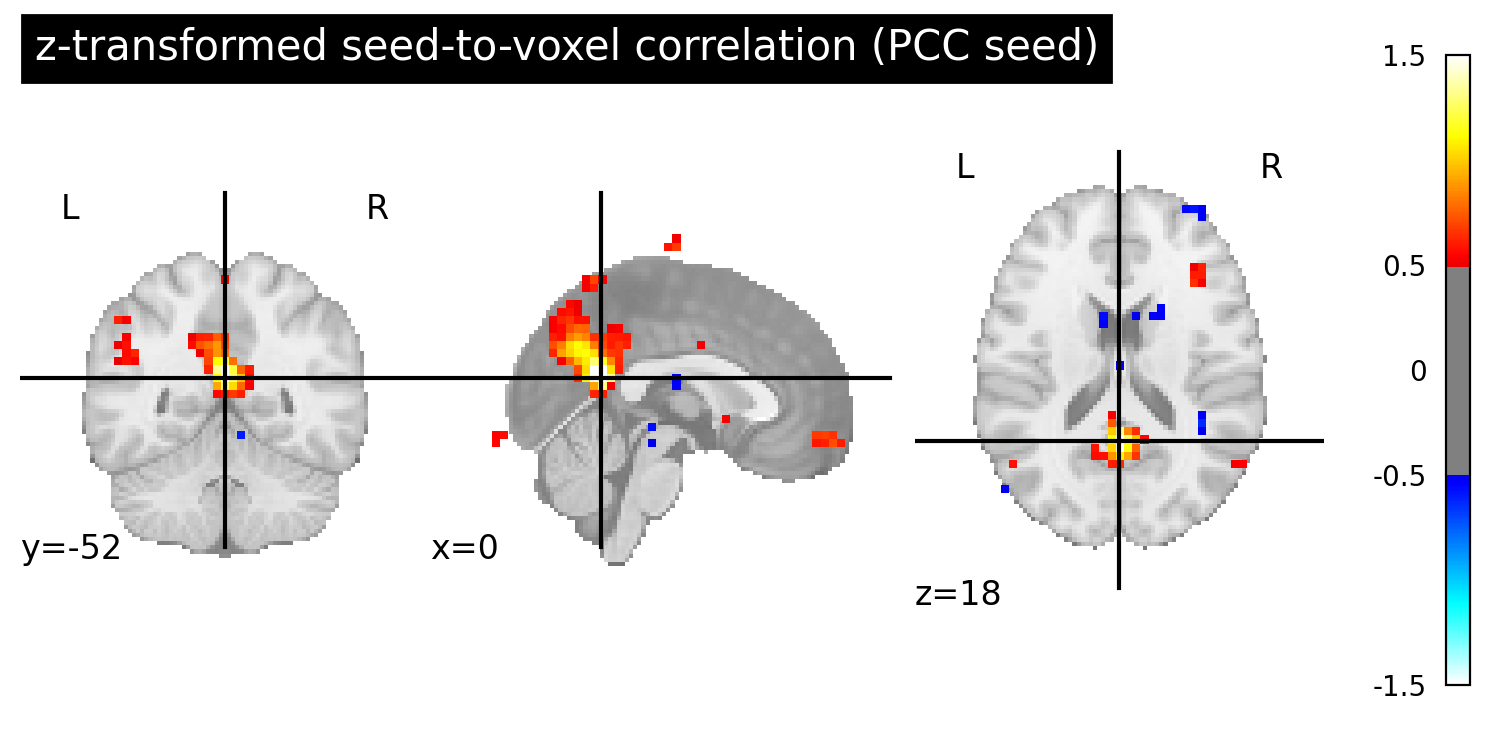

In [18]:
# YOUR CODE HERE
seed_to_voxel_correlations_fisher_z_img = brain_masker.inverse_transform(
    seed_to_voxel_correlations_fisher_z.T
)

display_z = plotting.plot_stat_map(
    seed_to_voxel_correlations_fisher_z_img,
    threshold=0.5,
    vmax=1.5,
    cut_coords=pcc_coords[0],
    title="z-transformed seed-to-voxel correlation (PCC seed)",
)
# raise NotImplementedError()

<div class='alert alert-info'>
  <b>ToThink</b> (0 points): You’ll notice very high correlations in voxels near the PCC seed, but also strong correlations in distant areas such as medial prefrontal cortex (mPFC).  
  What does this pattern tell us about the PCC’s functional connectivity?
</div>

<details>
  <summary><b>Answer (click to expand)</b></summary>

- **Local high correlations ≠ long-range connectivity:**  
  Very strong correlations right around the PCC largely reflect **spatial proximity** (shared signal, point-spread of the BOLD response, smoothing, partial volume) and **temporal autocorrelation**. These local effects are expected even without true long-range coupling.

- **Distant mPFC correlations imply network-level coupling:**  
  Robust synchrony between PCC and **mPFC**—despite their distance—suggests they belong to a common **large-scale functional network** (the default mode network). This captures **temporal co-fluctuation** rather than physical distance or direct structural pathways.

- **What functional connectivity means here:**  
  FC indicates **synchronised BOLD dynamics** between regions (shared neural processes or common inputs), not necessarily direct monosynaptic connections.

- **Caveats that can modulate the map:**  
  Residual confounds (e.g., motion, physiological noise, global signal), the chosen preprocessing (e.g., smoothing, band-pass), and masking choices can all influence both local and long-range correlations.

</details>

#### 1.6 Comparing to Meta-Analytic Results

It is often helpful to compare your findings with results from a meta-analysis. Doing so can provide insights into the functional role of the brain region you are investigating. One useful tool for this purpose is **Neurosynth**, a platform that enables large-scale meta-analyses of neuroimaging data based on a comprehensive database of published studies.

Among other features, Neurosynth allows you to examine how strongly a particular brain location correlates with activity across the rest of the brain. To try this out:

1. Visit the [Neurosynth website](https://neurosynth.org/).
2. Click on **Locations** in the top menu.
3. Enter the PCC coordinates: **x = 0, y = -52, z = 18**.
4. Adjust the threshold to **0.5** to match our plot above.

Your results should look similar to [this example](https://neurosynth.org/locations/0_-52_18_6/) (note: be sure to set the threshold to 0.5 using the slider on the right).

<div class='alert alert-info'>
    <b>ToThink</b> (0 points): How do our results in a single participant compare to the meta-analytic result?  
    What does this tell us about the functional network that we identified?
</div>

<details>
<summary><b>Solution</b></summary>

When comparing the single participant’s results to the meta-analytic map, we see that the identified region overlaps substantially with areas consistently implicated across many studies. This overlap suggests that our participant’s network is not a random finding but reflects a well-established functional network. Specifically, it indicates that the posterior cingulate cortex (PCC) is part of the default mode network, which is reliably observed in both individual data and large-scale meta-analyses. However, you will see that the correlations include broader regions in the meta-analytic map. It is possible to make these broader correlations in individual participants, but this requires a substantially longer acquisition.

</details>

#### 1.7 Seed-to-Voxel Correlation with a Different Seed

Up to this point, we have generated a seed-based correlation map using the posterior cingulate cortex (PCC), with coordinates taken from a published study. But how sensitive are our results to the exact seed location? For instance, could we reconstruct the default mode network with a seed in the mPFC?

<div class='alert alert-warning'>
    <b>ToDo</b> (3 points): Perform a new seed-based correlation analysis using the mPFC as the seed, at coordinates <code>[(−3, 44, −2)]</code>.  
    Follow these steps:
    <ol>
        <li>Define a <code>NiftiSpheresMasker</code> centred on the mPFC coordinates, including confound regression and filtering (as before).</li>
        <li>Extract the seed time series and regress out confounds.</li>
        <li>Z-score the seed time series and the whole-brain time series.</li>
        <li>Compute voxel-wise correlations with the seed using the dot product approach.</li>
        <li>Reconstruct the correlation values into a NIfTI image.</li>
    </ol>
    Save the resulting image in a variable named <code>sca_mPFC</code>.
</div>

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

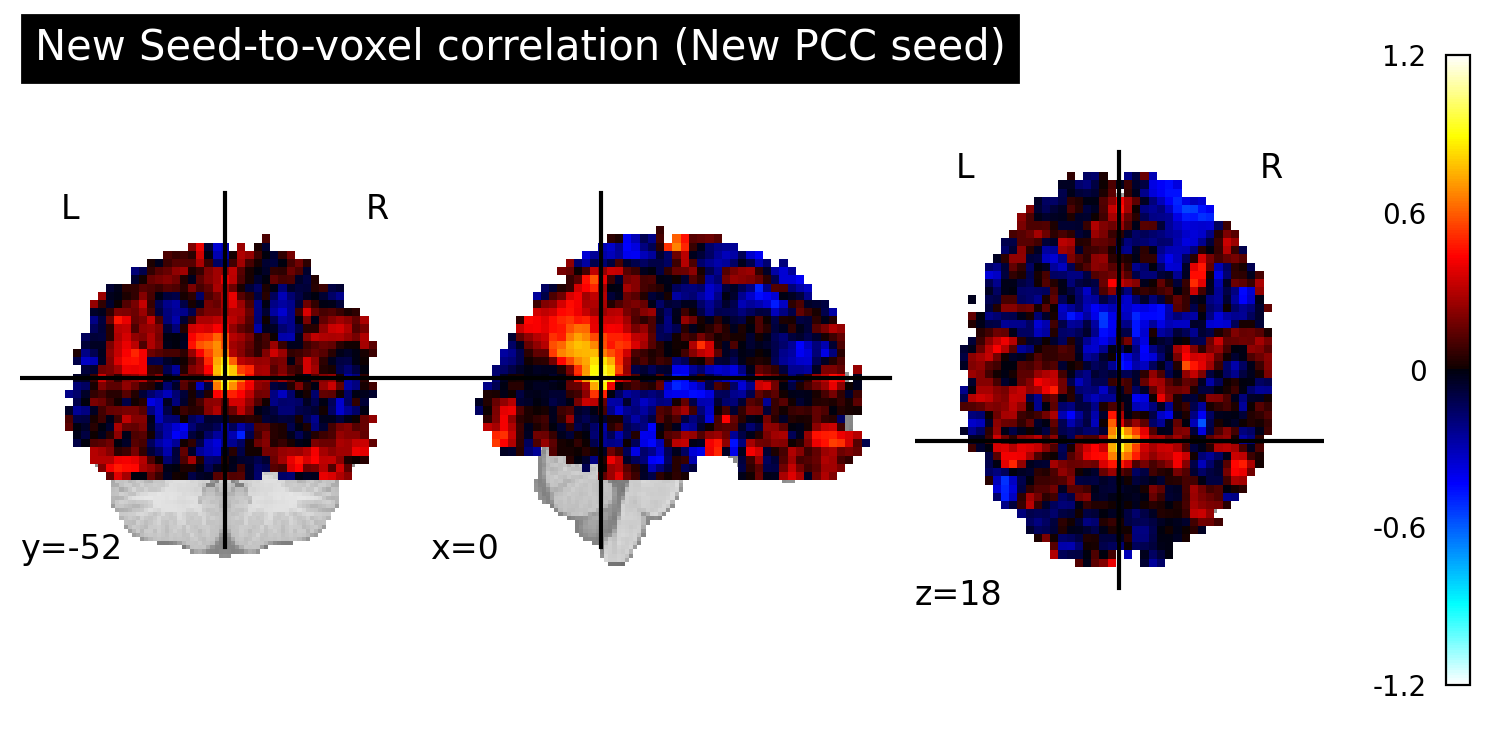

In [61]:
# YOUR CODE HERE


new_pcc_coords=(-3, 44, -2)

# defining a sphere around coordinates 
new_seed_masker = NiftiSpheresMasker(
    [new_pcc_coords],  # <-- list containing the tuple
    radius=4,
    detrend=True,
    standardize="zscore_sample",
    low_pass=0.1,
    high_pass=0.01,
    t_r=TR,
    memory="nilearn_cache",
    memory_level=1,
    verbose=0,
)

seed_time_series_with_confounds = seed_masker.fit_transform(
    func_filename, confounds=[confound_filename]
)

seed_to_voxel_correlations = (
    np.dot(brain_time_series.T, seed_time_series_with_confounds) / seed_time_series_with_confounds.shape[0]
)

seed_to_voxel_correlations_fisher_z = np.arctanh(seed_to_voxel_correlations)

sca_mPFC = brain_masker.inverse_transform(
    seed_to_voxel_correlations.T
)

display = plotting.plot_stat_map(
    sca_mPFC,
    vmin=-1.2,
    vmax=1.2,
    cut_coords=pcc_coords[0],
    title="New Seed-to-voxel correlation (New PCC seed)",
)

display.add_markers(
    marker_coords=new_pcc_coords, marker_color="b", alpha=0.5, marker_size=200
)

# raise NotImplementedError()

In [62]:
# Feedbacl cell
import nibabel as nib

if "sca_mPFC" not in locals():
    print('The variable "sca_mPFC" is not defined. Check that you created and named the variable correctly.')
elif not isinstance(sca_mPFC, nib.Nifti1Image):
    print('That is not the expected format. "sca_mPFC" should be a NIFTI image')
elif np.max(sca_mPFC.get_fdata()) < 0.8:
    print('We expected larger values. Please check your code.')
else:
    print('Your answer passed the automated checks.')

Your answer passed the automated checks.


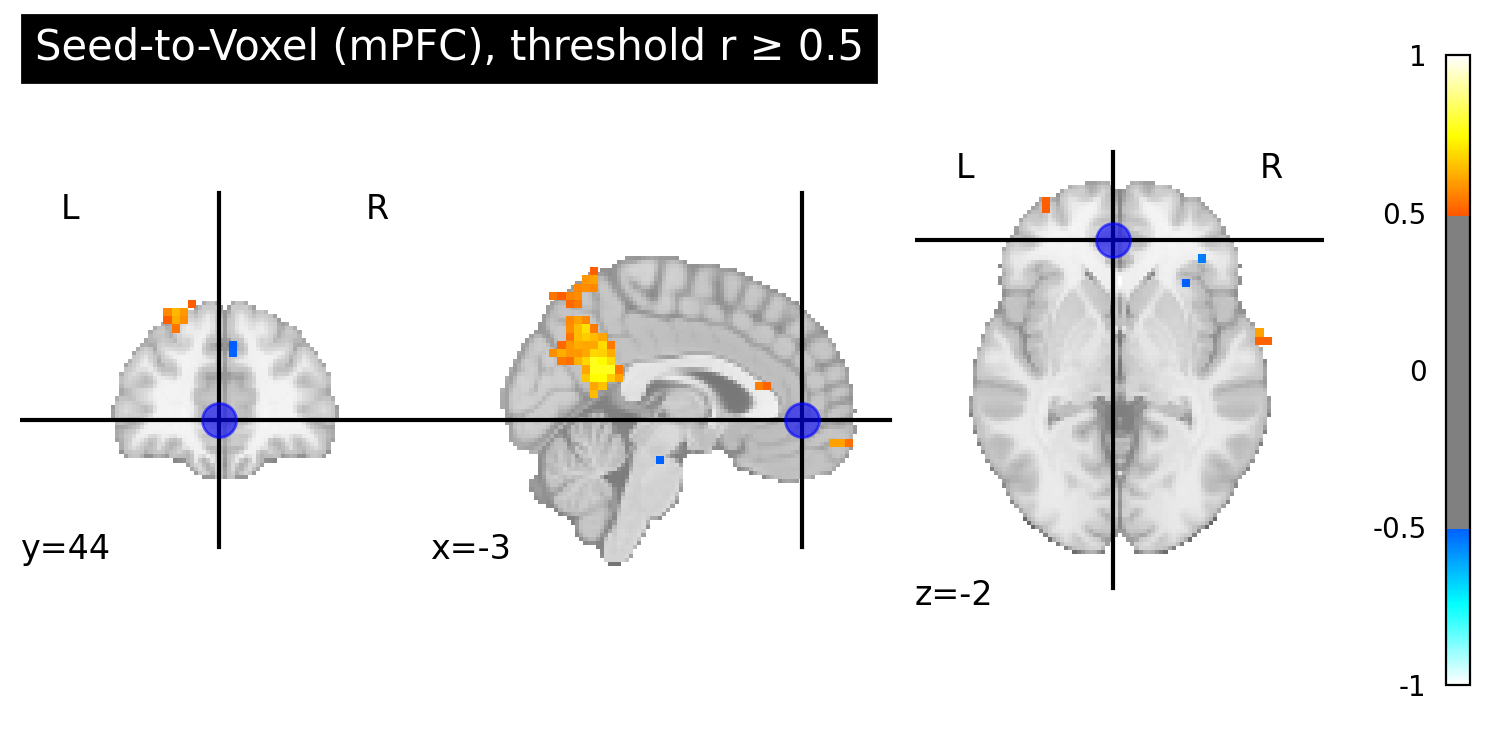

In [21]:
from nilearn import plotting

mpfc_coords = [(-3, 44, -2)]

# Plot the thresholded z-map
display = plotting.plot_stat_map(
    sca_mPFC,
    threshold=0.5,                # r-threshold
    vmax=1,                     # cap colour scale at 1
    cut_coords=mpfc_coords[0],     # centre slices on the mPFC seed
    title="Seed-to-Voxel (mPFC), threshold r ≥ 0.5",
    cmap="cold_hot"
)

# Mark the seed location
display.add_markers(
    marker_coords=mpfc_coords,
    marker_color="blue",
    marker_size=150,
    alpha=0.6
)

<div class='alert alert-info'>
    <b>ToThink</b> (0 points): How do the results obtained with the mPFC seed compare to those from the previous PCC seed and to the meta-analytic map?
</div>

<details>
<summary><b>Answer</b></summary>

When using the mPFC seed, the correlation with the PCC is weaker compared to when the PCC itself was used as the seed. This illustrates how the exact choice of seed region can affect the resulting connectivity pattern.  
Nevertheless, the overall network remains broadly consistent with the meta-analytic map, confirming that both regions are part of the same large-scale functional network (the default mode network), even though the strength of their direct correlation differs.
</details>

### 1.8 Seed-to-Voxel Correlation with an Atlas-Based ROI

So far, we have used spherical seeds defined by single coordinates. While simple, this approach can be problematic: a sphere placed arbitrarily in the brain may overlap with more than one functional network, especially near network boundaries.  

A more robust alternative is to define the seed as a region of interest (ROI) from an anatomical atlas or a functional parcellation. By using an anatomically defined area, we ensure that the seed corresponds to a well-characterised brain region rather than an arbitrary sphere. This typically yields results that are more stable and interpretable, and allows us to compare connectivity across participants and studies in a more meaningful way.

We are using the MSDL atlas in this example. The atlas consists of maps that indicate the probably of a given voxel belonging to a given region. We can use these maps to define our seed region. We will use the map for the posterior cingulate cortex provided in the atlas.

If you are interested, you can read more about how the atlas was calculated in this paper: https://doi.org/10.1016/j.neuroimage.2013.04.007 (Note: This is quite technical and not required for this tutorial).

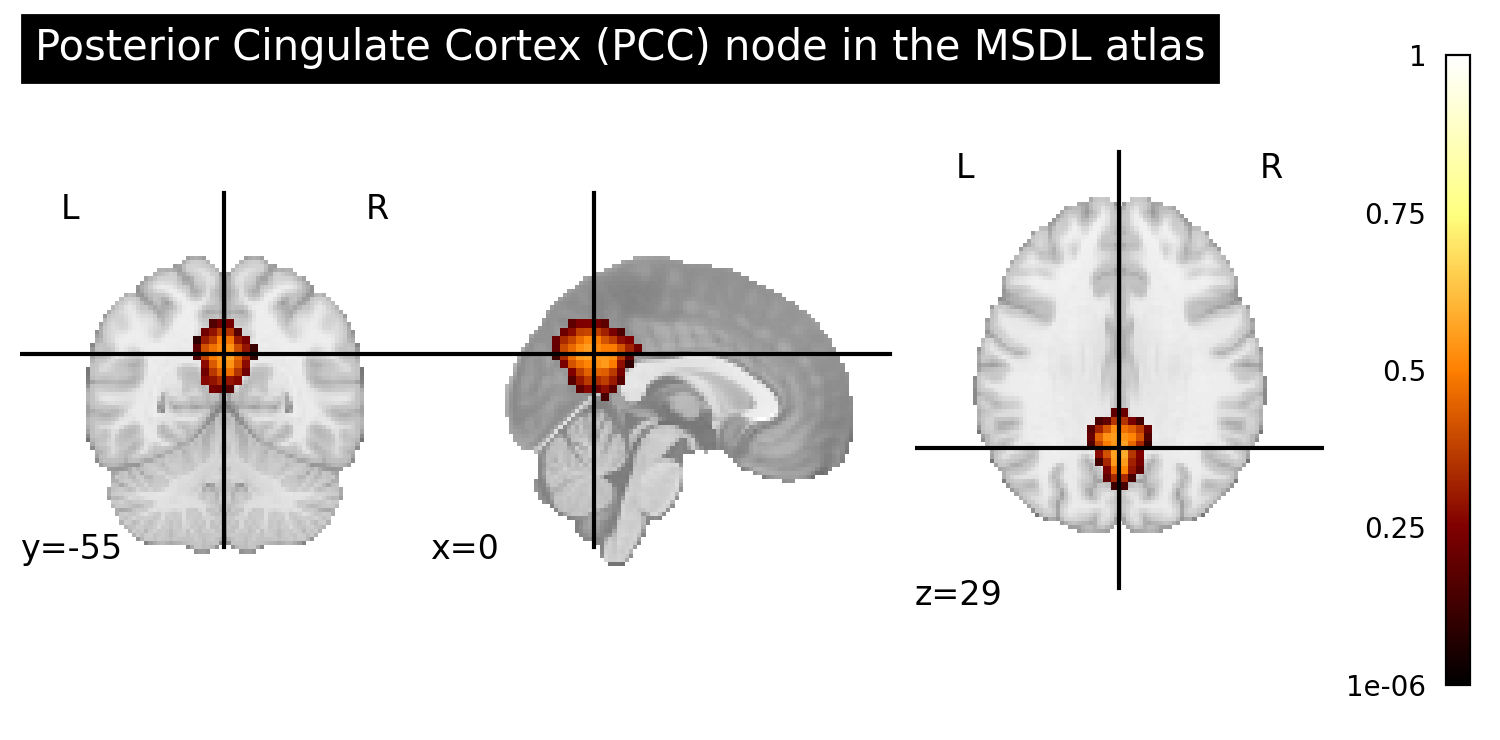

In [22]:
# Load the MSDL atlas
from nilearn import datasets, plotting, image

atlas_data = datasets.fetch_atlas_msdl()
atlas_filename = atlas_data.maps

# Select the PCC ROI (index 4 in the MSDL atlas)
pcc_roi_img = image.index_img(atlas_filename, 4)

# Plot the PCC ROI
display_pcc = plotting.plot_stat_map(
    pcc_roi_img,
    colorbar=True,
    cmap="afmhot",
    vmin=0.0,
    vmax=1.0,
    title="Posterior Cingulate Cortex (PCC) node in the MSDL atlas",
)

We can use the probablistic map from the atlas to calculate a weighted average of the BOLD signal in the PCC. It's weighted by the probability of a voxel belonging to the PCC. 

In [23]:
from nilearn.maskers import NiftiMapsMasker
from nilearn import image

# Define a masker for the PCC ROI (index 4 in the MSDL atlas)
pcc_roi_img = image.index_img(atlas_filename, 4)
pcc_masker = NiftiMapsMasker(
    maps_img=pcc_roi_img,
    standardize="zscore_sample",
    memory="nilearn_cache",
    memory_level=1,
    verbose=0,
)

# Extract the seed time series from the functional data, regressing out confounds
pcc_masker.fit(func_filename)
pcc_seed_ts = pcc_masker.transform(func_filename, confounds=confound_filename)

<div class='alert alert-warning'>
    <b>ToDo</b> (1 point):  
    Perform a seed-based correlation analysis (SCA) using the time series extracted from the **probabilistic PCC ROI**.  
    To do this, follow these steps:
    <ol>
        <li>Extract and flatten the PCC seed time series to obtain a 1D vector of length <code>T</code>.</li>
        <li>Z-score both the seed time series and the whole-brain voxel time series.</li>
        <li>Compute voxel-wise correlations with the seed using the dot product of z-scored signals, normalised by <code>(T - 1)</code>.</li>
        <li>Project the correlation values back into a brain image using <code>brain_masker.inverse_transform</code>.</li>
    </ol>
    Save the resulting image in a variable named <code>pcc_prob_correlation_img</code>.
</div>

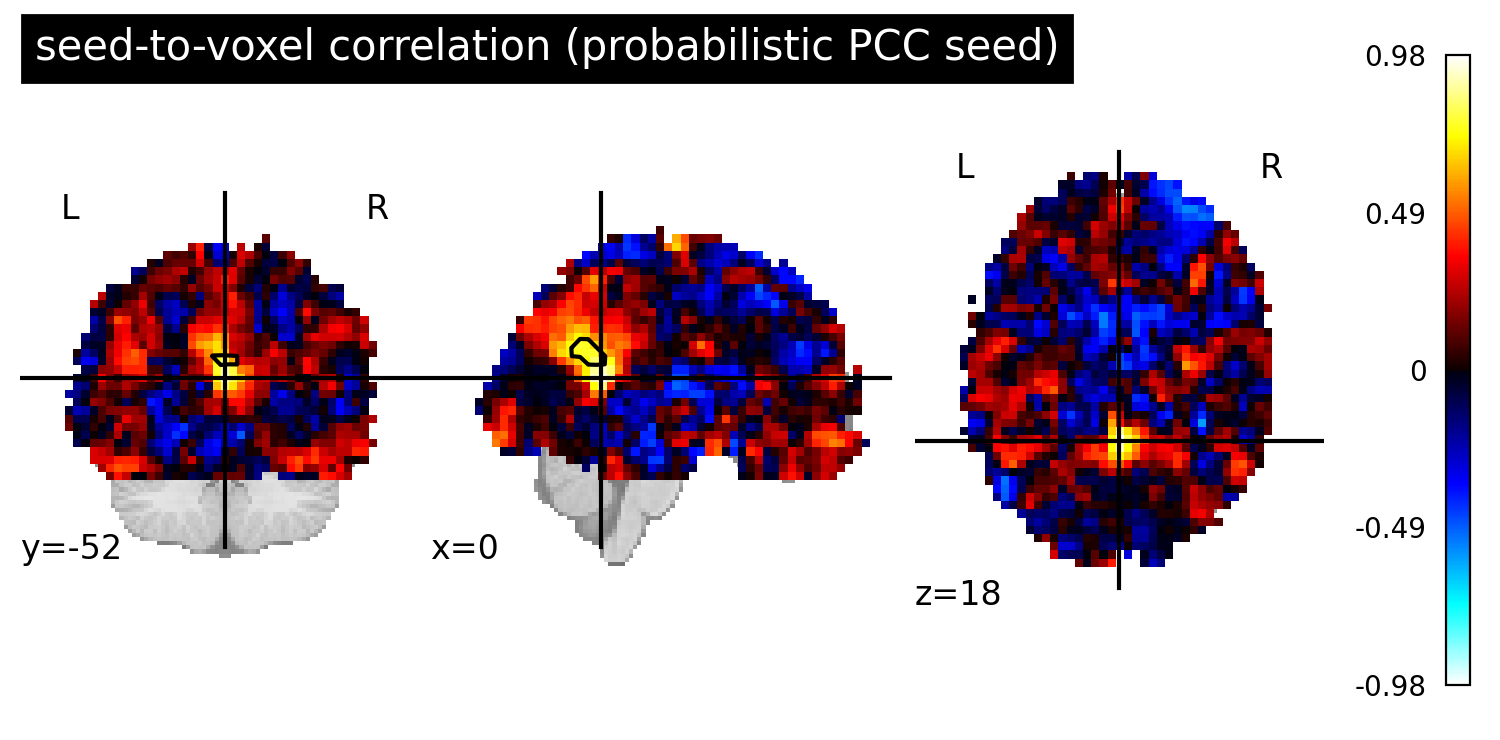

In [24]:
# YOUR CODE HERE
seed_to_voxel_correlations = (
    np.dot(brain_time_series.T, seed_time_series_with_confounds) / seed_time_series_with_confounds.shape[0]
)
seed_to_voxel_correlations_fisher_z = np.arctanh(seed_to_voxel_correlations)
pcc_prob_correlation_img = brain_masker.inverse_transform(
    seed_to_voxel_correlations.T
)

display = plotting.plot_stat_map(
    pcc_prob_correlation_img,
    cut_coords=pcc_coords[0],
    title="seed-to-voxel correlation (probabilistic PCC seed)",
)
# thresholding the probablistic map at 0.5
thresholded_atlas = image.threshold_img(image.index_img(atlas_filename, 4), threshold=0.5)
display.add_contours(thresholded_atlas, levels=[0.5], colors='k')

# raise NotImplementedError()

In [25]:
# Feedback cell
import nibabel as nib

if "pcc_prob_correlation_img" not in locals():
    print('The variable "pcc_prob_correlation_img" is not defined. Check that you created and named the variable correctly.')
elif not isinstance(pcc_prob_correlation_img, nib.Nifti1Image):
    print('That is not the expected format. "pcc_prob_correlation_img" should be a NIFTI image')
elif np.max(pcc_prob_correlation_img.get_fdata()) < 0.7:
    print('We expected a larger value. Please check your code.')
else:
    print('Well done! Your answer passed the automated checks.')

Well done! Your answer passed the automated checks.


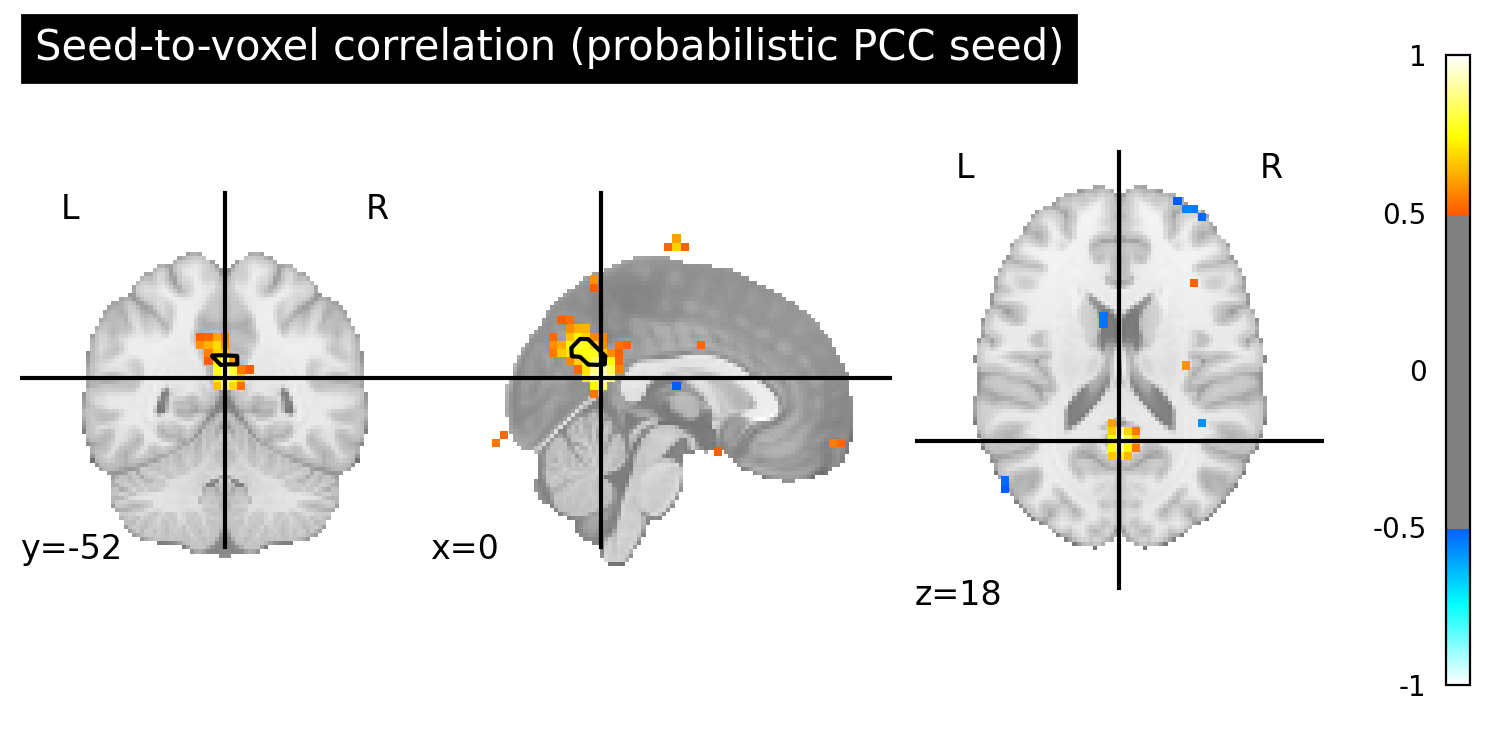

In [26]:
from nilearn import plotting, image

# Plot the seed-to-voxel correlation map derived from the probabilistic PCC seed
display_pcc_prob = plotting.plot_stat_map(
    pcc_prob_correlation_img,
    cut_coords=tuple(pcc_coords[0]),   # centre slices on the PCC seed (x, y, z)
    title="Seed-to-voxel correlation (probabilistic PCC seed)",
    colorbar=True,
    threshold=0.5,
    vmax=1
)

# Threshold the probabilistic PCC atlas map at 50% for visualisation
pcc_prob_map = image.index_img(atlas_filename, 4)
pcc_prob_50 = image.threshold_img(pcc_prob_map, threshold=0.5)

# Overlay the 50% contour to show the atlas-defined PCC boundary
display_pcc_prob.add_contours(
    pcc_prob_50,
    levels=[0.5],
    colors="k",
    linewidths=1.5
)

### 1.9 Seed-to-Voxel Connectivity via a GLM (Seed Time Series as Regressor)

An alternative to correlation is to estimate voxelwise connectivity with a **general linear model (GLM)**, using the seed time series as a regressor. This yields a **beta map** (effect size of the seed regressor) and, optionally, **t-statistics** that account for confounds and residual variance.

**Idea:** For each voxel’s time series \(y_v(t)\), fit  
$
y_v(t) = \beta_{\text{seed}}\,\text{seed}(t) + \mathbf{C}(t)\boldsymbol{\beta}_v + \alpha_v + \varepsilon_v(t),
$
where $\mathbf{C}(t)$ contains confound regressors (motion, aCompCor, etc.) and $(\alpha_v$) is the intercept.

#### Steps
1. Extract the seed time series (e.g., from your probabilistic PCC ROI) → `pcc_seed_ts` (shape `(T,)`).
2. Prepare a design matrix with columns: **seed**, **confounds**, and an **intercept**.
3. Fit OLS voxelwise to obtain:
   - **Beta** for the seed regressor (effect size map).
   - **t-statistic** for the seed regressor (optional but useful).
4. Back-project the beta / t values into NIfTI images with `brain_masker.inverse_transform`.

In [27]:
import numpy as np
import pandas as pd

# 1) Ensure correct shapes and z-score the seed
seed = np.asarray(pcc_seed_ts).ravel()
T = seed.shape[0]

# 2) Build design matrix: [seed | confounds | intercept]
confounds = pd.read_csv(confound_filename, sep='\t').values
X = np.column_stack([seed, confounds, np.ones(T)])
p = X.shape[1]

# 3) Response matrix (time × voxels)
Y = np.asarray(brain_time_series)  # shape (T, N_vox)

# Optional standardisation (keeps interpretation of beta similar to correlation)
Y = (Y - Y.mean(axis=0, keepdims=True)) / Y.std(axis=0, ddof=1, keepdims=True)
X[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std(ddof=1)  # z-score seed

# 4) OLS solution
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
betas = XtX_inv @ (X.T @ Y)             # shape (p, N_vox)

# 5) Residual variance and t-stats for the seed beta (row 0)
res = Y - X @ betas
df = T - p
sigma2 = (res**2).sum(axis=0) / df      # shape (N_vox,)
var_beta_seed = sigma2 * XtX_inv[0, 0]  # scalar * per-voxel sigma²
t_seed = betas[0, :] / np.sqrt(var_beta_seed)

# 6) Back-project to NIfTI images
pcc_seed_beta_img_glm = brain_masker.inverse_transform(betas[0, :])
pcc_seed_t_img_glm    = brain_masker.inverse_transform(t_seed)

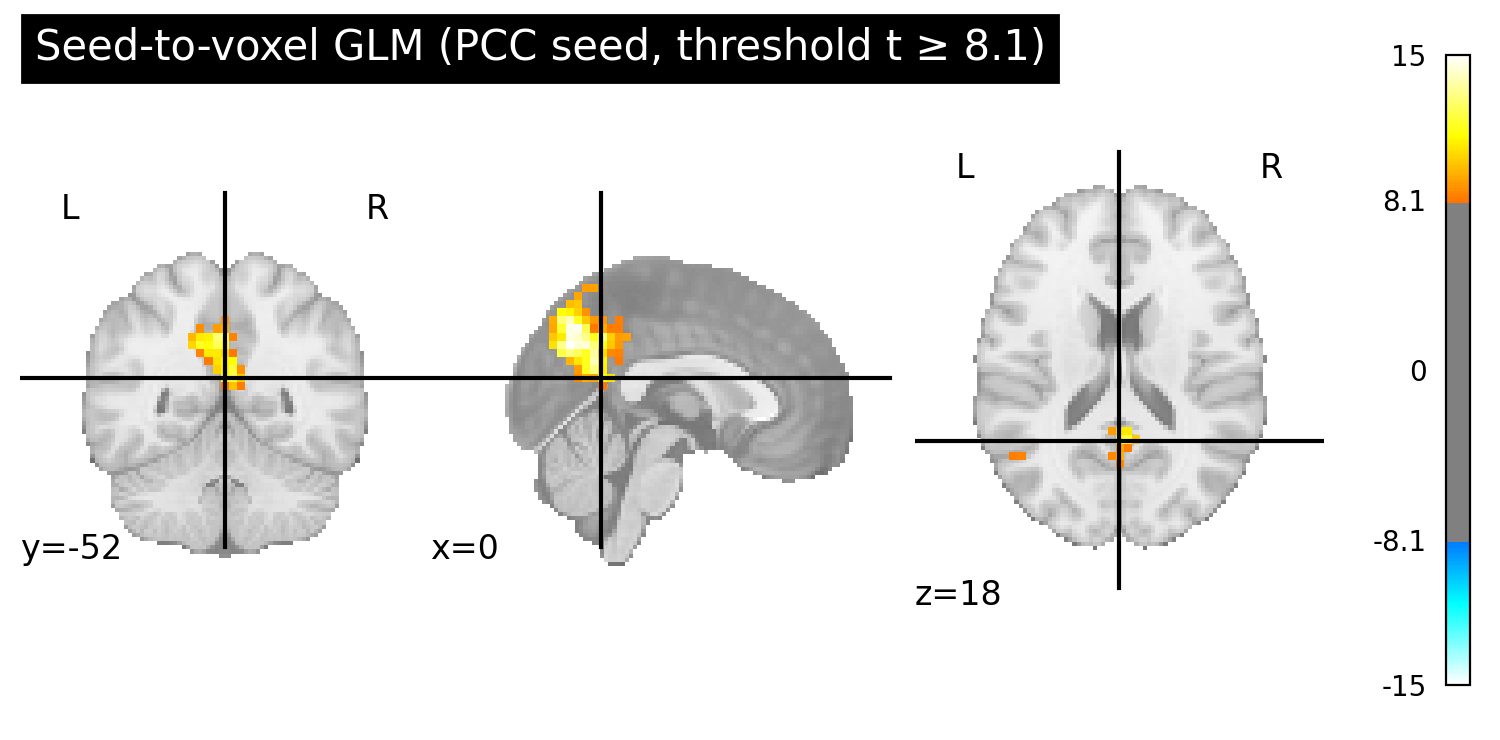

In [28]:
from nilearn import plotting

# Plot the thresholded t-map for the PCC seed regressor
display_pcc_glm = plotting.plot_stat_map(
    pcc_seed_t_img_glm,
    threshold=8.1,                 # threshold equivalent to r ≈ 0.5 (for n ≈ 200)
    vmax=15,                       # set upper bound of colour scale
    cut_coords=pcc_coords[0],     # centre slices on the PCC seed
    title="Seed-to-voxel GLM (PCC seed, threshold t ≥ 8.1)",
    cmap="cold_hot",
    colorbar=True
)

<div class='alert alert-info'>
    <b>ToThink</b> (0 points):  
    Why do you think GLM-based seed-to-voxel analyses are less commonly used than simple correlation maps in resting-state fMRI?  
    Consider aspects such as computational cost, interpretability, and the way noise is handled in resting-state data.
</div>

<details>
<summary><b>Answer</b></summary>

GLM-based approaches provide formal statistical inference (e.g. t-maps), but in practice they are not widely used for resting-state SCA because:

- **Correlation already captures the main effect**: with a single continuous regressor (the seed time series), the GLM beta is proportional to the correlation coefficient.  
- **Resting-state regressors**: resting-state fMRI typically includes many nuisance regressors (motion, aCompCor, physiological signals, etc.) to deal with noise. Unlike task fMRI, there is no averaging across repeated trials. Including all of these in a GLM reduces the available degrees of freedom, leading to a loss of statistical power.  
- **Interpretation focus**: in resting-state studies, the main interest is usually in connectivity patterns rather than formal voxelwise inference.

For these reasons, simple correlation maps (often Fisher-z transformed) are the standard approach in resting-state SCA.
</details>

## 2. The Functional Connectome
### 2.1 Parcellated Connectome
In the previous section, we calculated the correlation between the BOLD signal of a seed region and the rest of the brain. This is a very useful way to identify regions that are functionally connected to the seed region. However, it is also quite limited. We only get information about the connectivity of one region. In this section, we will calculate the correlation between all regions in the brain. This will give us a functional connectome, which is a matrix that shows the correlation between all regions in the brain. We could do this for each voxel in the brain. This is called a dense connectome. However, this is computationally very expensive. Instead, we will use a parcellation that assigns many voxels to one region based on an atlas. This is called a parcellated connectome.

We already worked with an atlas in the previous section. Here, we use the same atlas to calculate the correlation between all the regions in the atlas. Let's first look at the atlas.

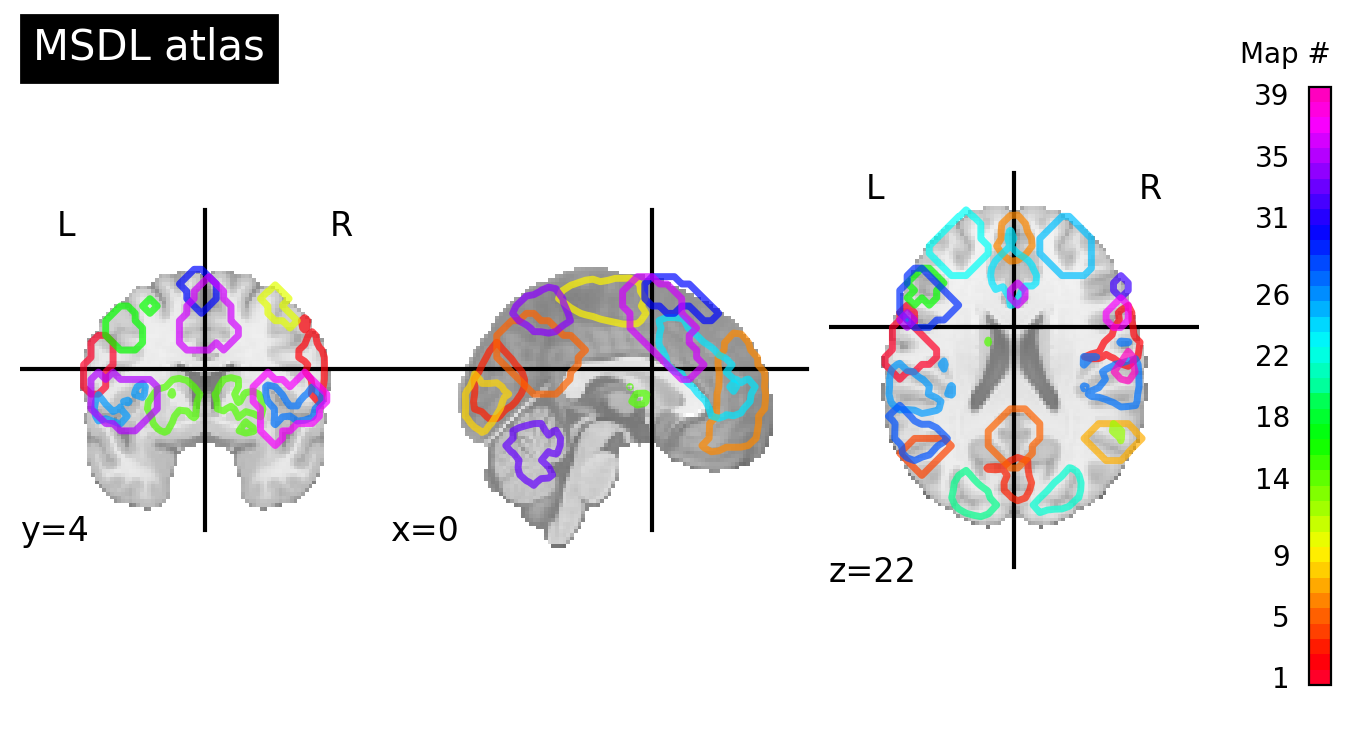

In [29]:
plotting.plot_prob_atlas(
    atlas_filename,
    title="MSDL atlas",
    colorbar=True,
)

In the figure above, each brain region from the atlas is shown with a distinct colour overlay. Notice that the regions are not perfectly separated but instead **partially overlap**. This is because the atlas is **probabilistic**: rather than assigning each voxel to a single region, it specifies the probability that a voxel belongs to each region. As a result, the same voxel can have non-zero probabilities for multiple regions. The colour bar indicates how colours map onto the different regions in the atlas.

To calculate the parcellated connectome, we calculate the weighted average of the BOLD signal within each region in the atlas. That's the same as we did for the seed region in the previous section, but applied to all regions in the atlas.

In [30]:
from nilearn.maskers import NiftiMapsMasker

# Create a masker to extract time series from the atlas-defined ROIs
atlas_masker = NiftiMapsMasker(
    maps_img=atlas_filename,
    standardize="zscore_sample",   # z-score each time series
    memory="nilearn_cache",
    memory_level=2,
    verbose=1
)

# Extract ROI time series from the functional data while regressing out confounds
atlas_time_series = atlas_masker.fit_transform(
    func_filename,
    confounds=confound_filename
)

[NiftiMapsMasker.wrapped] loading regions from None


Resampling maps


Next, we want to compute the connectivity between all pairs of regions in the atlas.  
While we could implement this ourselves by looping over region time series and calculating pairwise correlations, **nilearn** provides a convenient tool for this: the <code>ConnectivityMeasure</code> class. This class can automatically compute correlation (or other connectivity metrics) across all atlas regions, returning the full connectivity matrix in one step.

In [31]:
from nilearn.connectome import ConnectivityMeasure

# Define a connectivity measure (here: full Pearson correlation)
correlation_measure = ConnectivityMeasure(kind="correlation")

# Compute the region-by-region correlation matrix from the atlas time series
# Note: fit_transform expects a list of subjects → wrap time series in [ ... ]
correlation_matrix = correlation_measure.fit_transform([atlas_time_series])[0]

Finally, we can visualize the correlation matrix using a matrix plot:

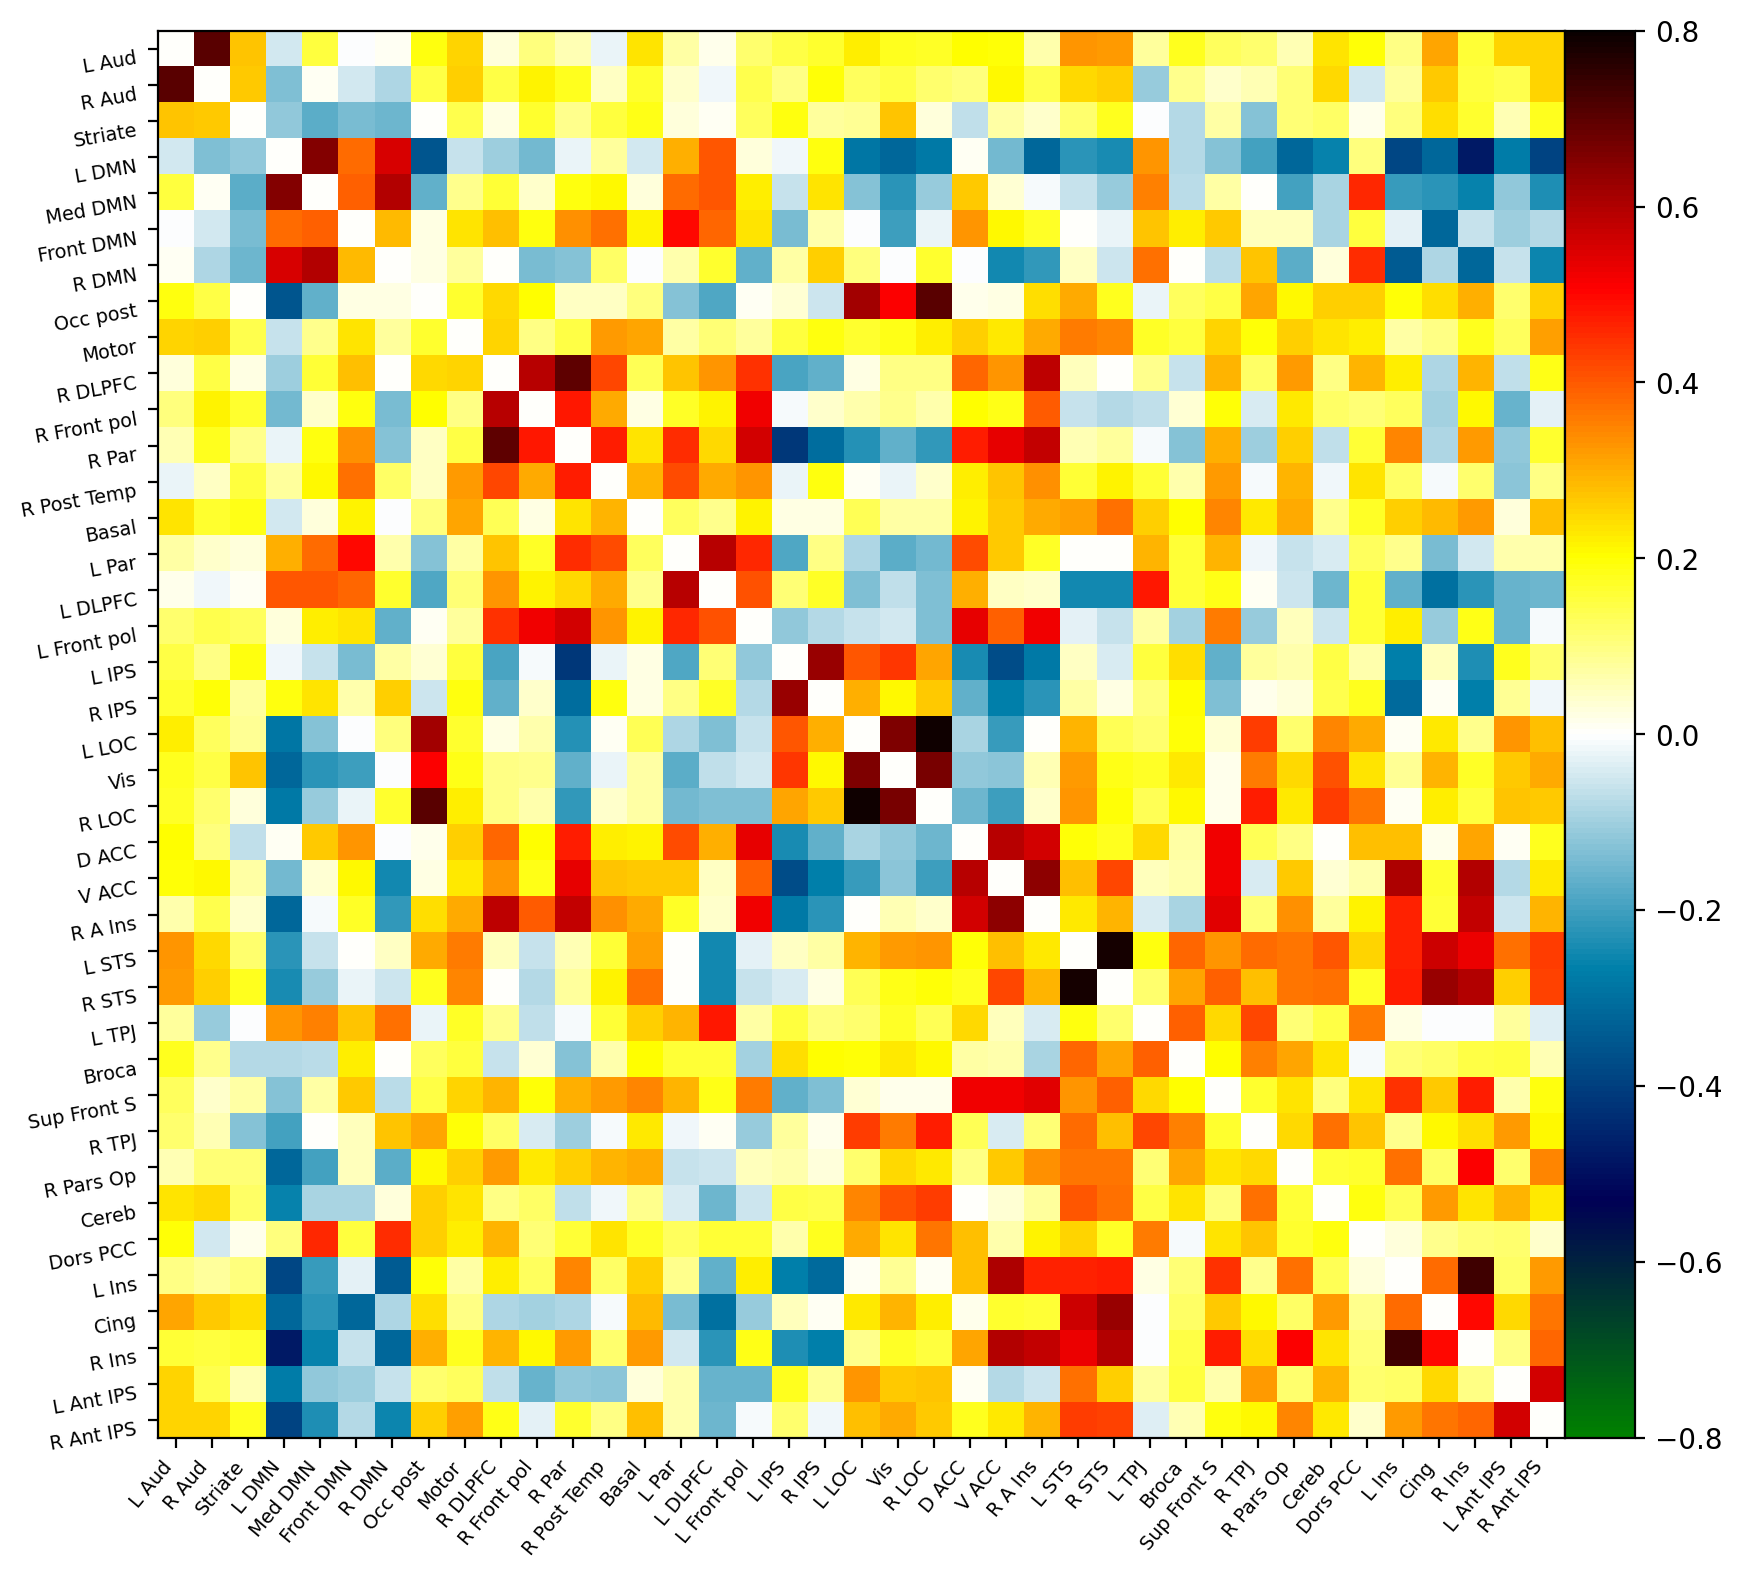

In [32]:
import numpy as np
from nilearn import plotting

# Set the diagonal to zero (ignore self-correlations for visualization)
np.fill_diagonal(correlation_matrix, 0)

# Plot the atlas-based correlation matrix
plotting.plot_matrix(
    correlation_matrix,
    labels=atlas_data["labels"],   # region names from the atlas
    figure=(10, 8),
    cmap="ocean_hot",
    vmin=-0.8,
    vmax=0.8,
    colorbar=True
)

So, what does this tell us?  
The correlation matrix reveals which regions have similar time courses, which is typically interpreted as evidence that they belong to the same functional network. For example, regions within the **default mode network (DMN)** show strong correlations with each other — exactly as expected for this well-established network.  

We can represent the same information in a more intuitive way using a **network graph**. In this view, each region is represented as a **node**, and the correlation between two regions is shown as an **edge**. The thickness (or weight) of the edge reflects the strength of the correlation.  

Nilearn provides a convenient function, <code>plot_connectome</code>, to visualise connectivity matrices as network graphs directly on a brain template.

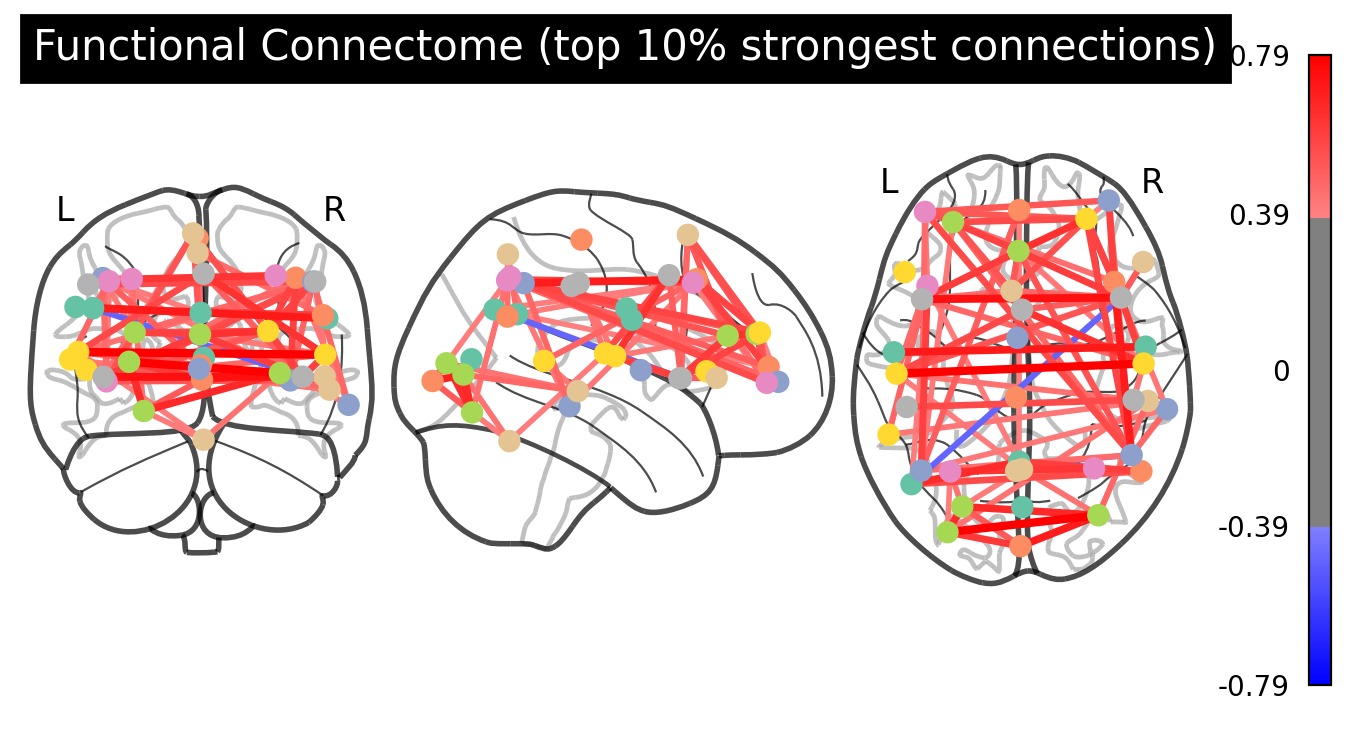

In [33]:
from nilearn import plotting

# Plot the connectome, keeping only the strongest 10% of edges
# (using edge_threshold="90%" means edges below the 90th percentile are removed)
plotting.plot_connectome(
    correlation_matrix,
    atlas_data.region_coords,
    edge_threshold="90%",
    colorbar=True,
    title="Functional Connectome (top 10% strongest connections)"
)

plotting.show()

<div class='alert alert-info'>
    <b>ToThink</b> (0 points):  
    In the figure above, what do you notice about the spatial arrangement of the strongest connections?  
    Which regions appear most strongly connected, and why do you think that might be?
</div>

<details>
<summary><b>Answer</b></summary>

The strongest connections are typically observed between **homologous regions in the left and right hemispheres**.  
This pattern reflects the high degree of interhemispheric coordination: corresponding regions in both hemispheres often share similar functions and are strongly coupled through the corpus callosum, leading to highly correlated time courses in resting-state fMRI.
</details>

<div class="alert alert-warning">
  <b>ToDo</b> (1 point):<br>
  So far, we have calculated the parcellated connectome for a single participant.<br>
  Now extend this analysis to all participants:  
  <ol>
    <li>Compute the connectome matrix for each participant.</li>
    <li>Average the matrices across participants.</li>
    <li>Store the resulting group-average connectome in a NumPy array named <code>average_connectome_matrix</code>.</li>
  </ol>
  💡<b>Tip:</b> The final matrix should have shape <code>(n_regions, n_regions)</code>, where <code>n_regions</code> is the number of ROIs in the atlas.
</div>

In [34]:
from nilearn import datasets

# Load the developmental fMRI dataset (10 subjects)
dataset = datasets.fetch_development_fmri(n_subjects=10)

# Functional data and confound files (lists of file paths, one per subject)
func_filenames = dataset.func
confound_filenames = dataset.confounds

In [35]:
# YOUR CODE HERE

n_subjects = len(func_filenames)
connectomes = []

for i in range(n_subjects):
    atlas_time_series = atlas_masker.fit_transform(
        func_filenames[i],
        confounds=confound_filenames[i]
    )
    corr_matrix = correlation_measure.fit_transform([atlas_time_series])[0]
    connectomes.append(corr_matrix)

average_connectome_matrix = np.mean(connectomes, axis=0)
# raise NotImplementedError()

[NiftiMapsMasker.wrapped] loading regions from None


[NiftiMapsMasker.wrapped] loading regions from None


________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/home/user/nilearn_data/development_fmri/development_fmri/sub-pixar124_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x7f58a4b4fd90>, { 'allow_overlap': True,
  'clean_kwargs': {},
  'detrend': False,
  'dtype': None,
  'high_pass': None,
  'high_variance_confounds': False,
  'keep_masked_maps': True,
  'low_pass': None,
  'maps_img': '/home/user/nilearn_data/msdl_atlas/MSDL_rois/msdl_rois.nii',
  'mask_img': None,
  'reports': True,
  'smoothing_fwhm': None,
  'standardize': 'zscore_sample',
  'standardize_confounds': True,
  't_r': None,
  'target_affine': None,
  'target_shape': None}, confounds=[ '/home/user/nilearn_data/development_fmri/development_fmri/sub-pixar124_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None

[NiftiMapsMasker.transform_single_imgs] Extracting region signals


/usr/local/lib/python3.10/dist-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x7f58a4b4fd90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


...

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/home/user/nilearn_data/development_fmri/development_fmri/sub-pixar008_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x7f58a6eaa050>, { 'allow_overlap': True,
  'clean_kwargs': {},
  'detrend': False,
  'dtype': None,
  'high_pass': None,
  'high_variance_confounds': False,
  'keep_masked_maps': True,
  'low_pass': None,
  'maps_img': '/home/user/nilearn_data/msdl_atlas/MSDL_rois/msdl_rois.nii',
  'mask_img': None,
  'reports': True,
  'smoothing_fwhm': None,
  'standardize': 'zscore_sample',
  'standardize_confounds': True,
  't_r': None,
  'target_affine': None,
  'target_shape': None}, confounds=[ '/home/user/nilearn_data/development_fmri/development_fmri/sub-pixar008_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None

[NiftiMapsMasker.transform_single_imgs] Extracting region signals


/usr/local/lib/python3.10/dist-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x7f58a6eaa050>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x7f58a6c74670>)


______________________________________nifti_maps_masker_extractor - 7.7s, 0.1min
[NiftiMapsMasker.transform_single_imgs] Cleaning extracted signals
________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[6233.34732 , ..., 5393.452052],
       ...,
       [6240.750173, ..., 5386.519359]]), detrend=False, standardize='zscore_sample', standardize_confounds=True, t_r=None, low_pass=None, high_pass=None, confounds=[ '/home/user/nilearn_data/development_fmri/development_fmri/sub-pixar008_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
______________________________________________filter_and_extract - 11.3s, 0.2min


In [36]:
print(average_connectome_matrix.shape)
print(correlation_matrix)

(39, 39)
[[0.         0.7034669  0.27146001 ... 0.16152248 0.25084919 0.25541097]
 [0.7034669  0.         0.26331555 ... 0.1553671  0.13864582 0.25356842]
 [0.27146001 0.26331555 0.         ... 0.16527361 0.06122733 0.17540062]
 ...
 [0.16152248 0.1553671  0.16527361 ... 0.         0.09422716 0.38453826]
 [0.25084919 0.13864582 0.06122733 ... 0.09422716 0.         0.55657205]
 [0.25541097 0.25356842 0.17540062 ... 0.38453826 0.55657205 0.        ]]


In [37]:
# Feedback cell
if "average_connectome_matrix" not in locals():
    print('The variable "average_connectome_matrix" is not defined. Check that you created and named the variable correctly.')
elif not average_connectome_matrix.shape == (39, 39):
    print('"average_connectome_matrix" should be a matrix with shape (39, 39)')
elif not np.max(average_connectome_matrix) > 0.9:
    print('We expected larger values. Please check you code.')
else:
    print('Your answer passed the automated checks.')

Your answer passed the automated checks.


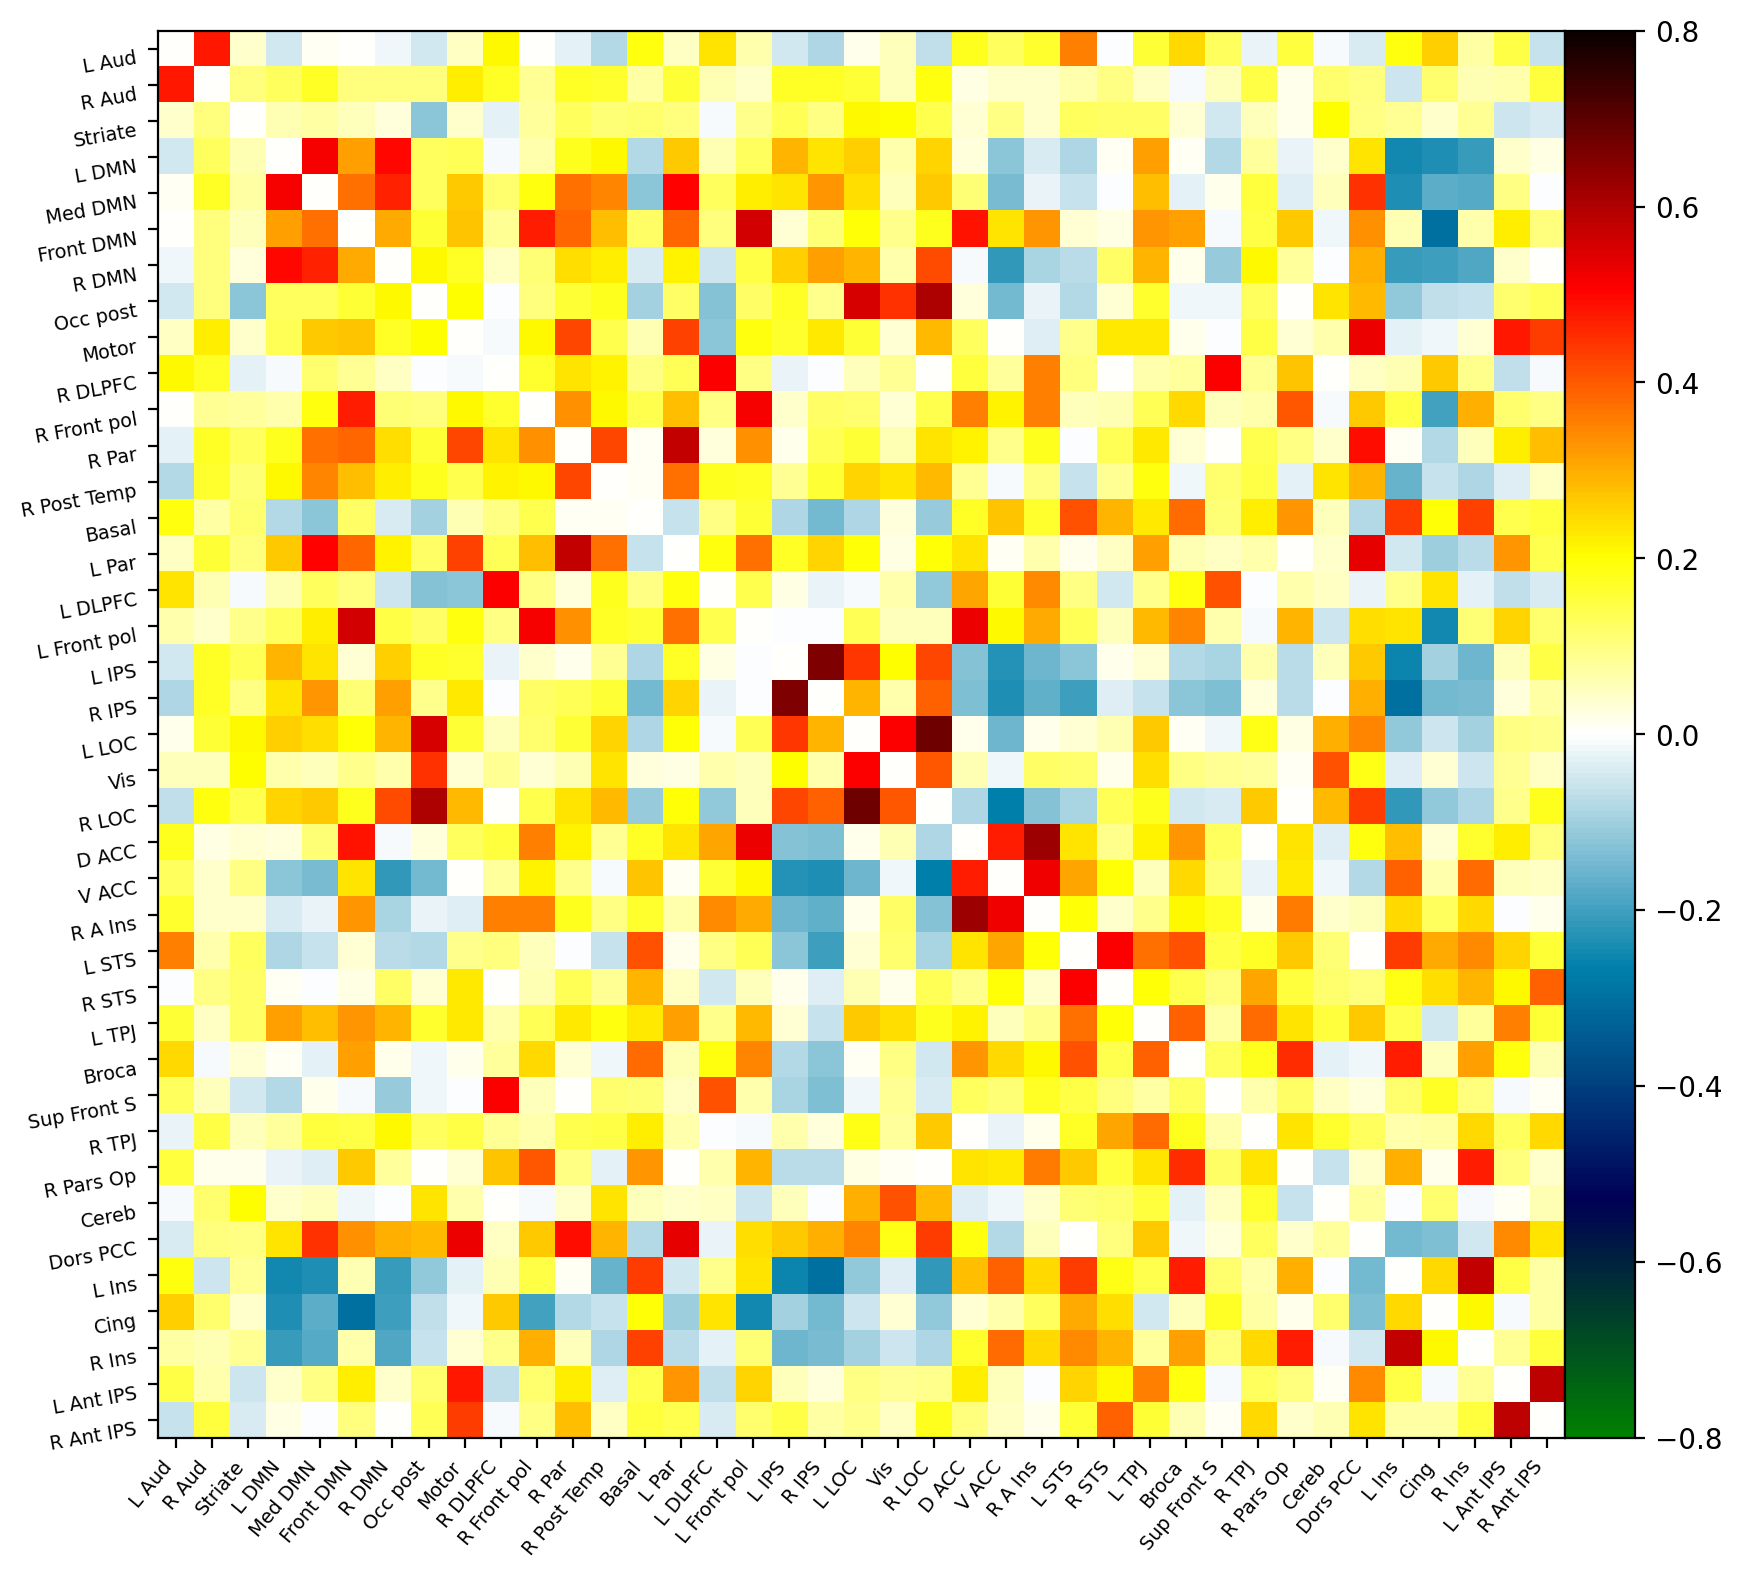

In [41]:
# Plot the average connectome matrix
np.fill_diagonal(average_connectome_matrix, 0)

plotting.plot_matrix(
    average_connectome_matrix,
    labels = atlas_data["labels"],
    figure=(10, 8),
    cmap='ocean_hot',
    vmax=0.8,
    vmin=-0.8,
    )

**What can we do with all of this information?**

One approach, if we have a sufficiently large sample, is to examine how each connection in the connectome relates to behavioural measures. For example, we might test whether the strength of a particular connection is associated with participants’ intelligence scores. This type of analysis is known as a **brain–wide association study (BWAS)**. However, establishing robust and reproducible brain–behaviour relationships typically requires very large datasets — often thousands of participants (see e.g. [Marek et al., 2022](https://doi.org/10.1038/s41586-022-04492-9)).  

Another approach is to characterise the connectome using **graph theory**. Graph-theoretical measures describe properties such as how efficiently information can be exchanged across the network, how well integrated or segregated the network is, and how robust it is to disruptions.  
We will explore these measures in the next section.

### 2.2 Graph Theory Analysis

**Graph theory** is a branch of mathematics concerned with the study of networks. A network consists of *nodes* (elements) and *edges* (connections between them). Examples range from social networks to the structure of the internet.  

In the context of brain connectivity, **nodes** correspond to brain regions, and **edges** represent functional connections between them. Graph theory provides a framework for describing the properties of these networks and for comparing them to theoretical or random models.  

In this section, we will focus on two fundamental graph measures:  

- **Degree**: the number of edges connected to a node. In brain networks, this reflects how many other regions a given region is directly connected to.  
- **Clustering coefficient**: a measure of how strongly a node’s neighbours are interconnected. This reflects the local cohesiveness of the network.  

To compute these measures on our connectome, we first need to **threshold the connectivity matrix**. Thresholding serves two purposes:  
1. It removes weak connections that are likely to reflect noise.  
2. It standardises the density of the network, making it possible to compare degree distributions across networks.  

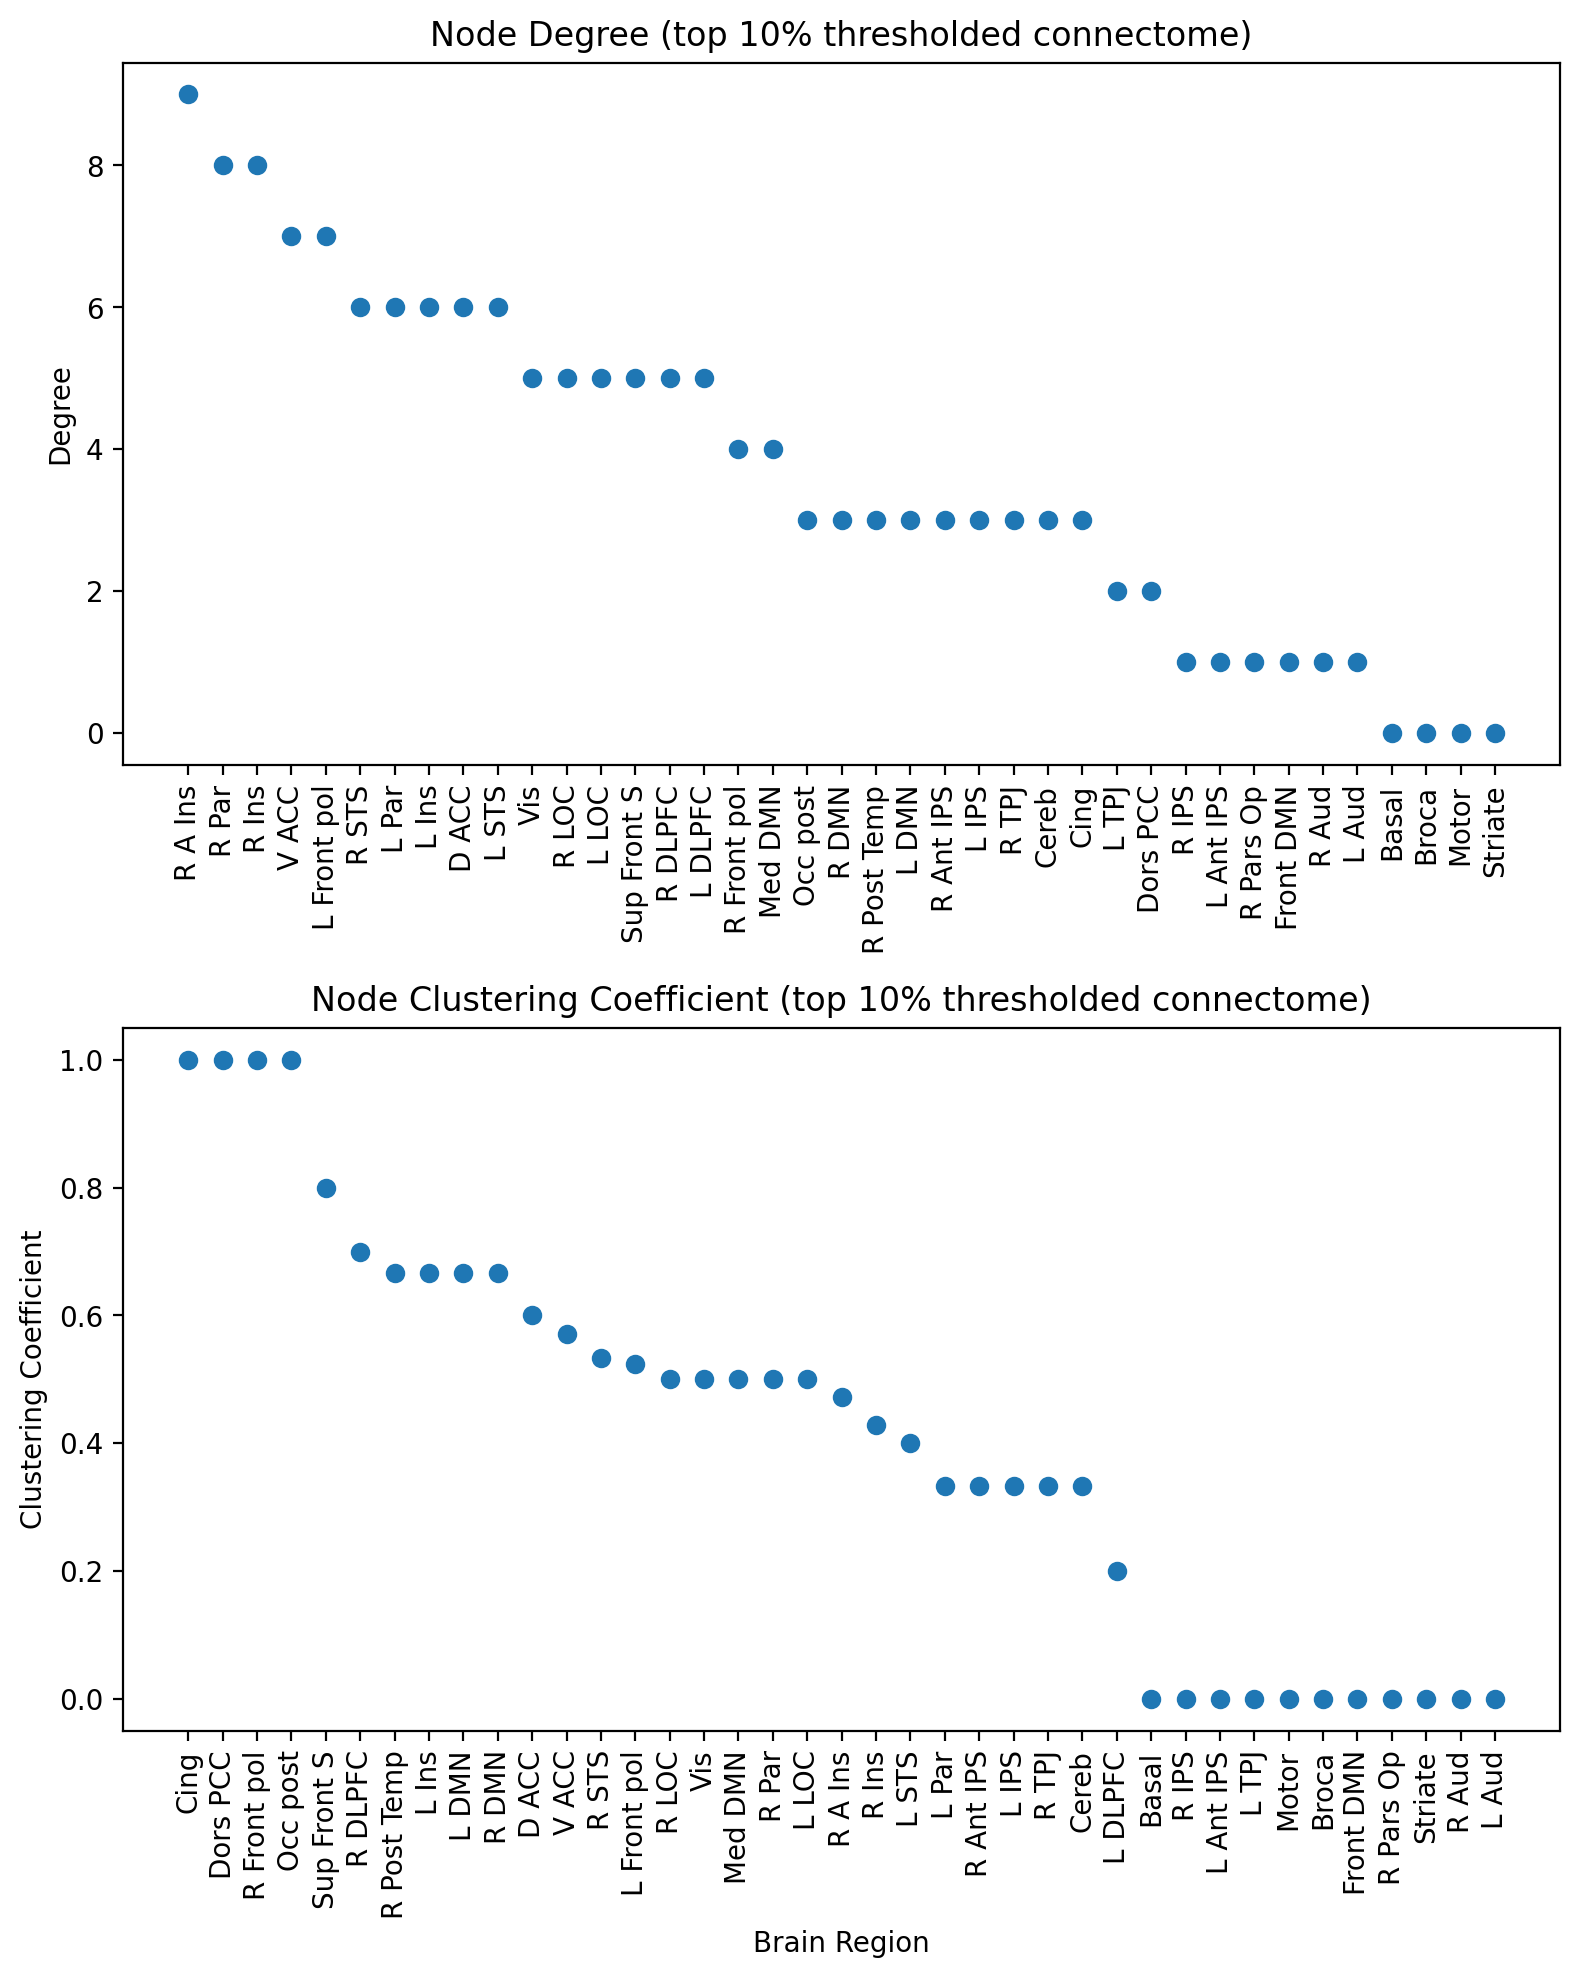

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# -------- Utilities ----------------------------------------

def proportional_threshold(W, proportion=0.1):
    """
    Keep the strongest `proportion` of absolute off-diagonal weights in W.
    Returns a thresholded (weighted) symmetric matrix with zero diagonal.
    """
    W = np.asarray(W, dtype=float)
    W = (W + W.T) / 2.0                  # enforce symmetry
    np.fill_diagonal(W, 0.0)             # no self-connections

    # Flatten upper triangle (excluding diagonal)
    iu = np.triu_indices_from(W, k=1)
    weights = np.abs(W[iu])

    # Determine cutoff at the given proportion (e.g., 0.1 keeps top 10%)
    if proportion <= 0 or proportion >= 1:
        raise ValueError("`proportion` must be in (0, 1).")
    k = max(1, int(np.floor(proportion * weights.size)))
    if k == 0:
        return np.zeros_like(W)
    cutoff = np.partition(weights, -k)[-k]

    # Apply threshold on absolute values
    keep = np.abs(W) >= cutoff
    W_thr = np.zeros_like(W)
    W_thr[keep] = W[keep]
    np.fill_diagonal(W_thr, 0.0)

    # Re-symmetrise to be safe
    return (W_thr + W_thr.T) / 2.0


def binarise_adjacency(W):
    """Convert a (weighted) adjacency matrix to binary (0/1), zero diagonal."""
    A = (np.asarray(W) > 0).astype(int)
    np.fill_diagonal(A, 0)
    return A


def degrees_und_binary(A):
    """Degree of each node in an undirected binary graph."""
    A = np.asarray(A)
    return A.sum(axis=0)


def clustering_coef_und_binary(A):
    """
    Clustering coefficient for an undirected binary graph.

    C_i = (2 * triangles_i) / (k_i * (k_i - 1)), with C_i = 0 if k_i < 2.
    Triangles per node: (A^3)_{ii} / 2 for undirected graphs without self-loops.
    """
    A = np.asarray(A, dtype=int)
    np.fill_diagonal(A, 0)
    A = ((A + A.T) > 0).astype(int)  # enforce undirected & binary
    k = A.sum(axis=0)
    # number of triangles touching each node
    A3_diag = np.diag(np.linalg.matrix_power(A, 3))
    triangles = A3_diag / 2.0
    denom = k * (k - 1) / 2.0
    C = np.zeros_like(k, dtype=float)
    valid = denom > 0
    C[valid] = triangles[valid] / denom[valid]
    return C

# -------- Analysis ---------------------------------------------------

# 1) Threshold the connectivity matrix: keep top 10% strongest edges
thresholded_matrix = proportional_threshold(correlation_matrix, proportion=0.10)

# 2) Binarise for graph metrics
A_bin = binarise_adjacency(thresholded_matrix)

# 3) Compute graph measures
degrees = degrees_und_binary(A_bin)
clustcoeff = clustering_coef_und_binary(A_bin)

# -------- Sorting for visualisation ------------------------------------------

labels = np.array(atlas_data["labels"])

deg_sort_idx = np.argsort(degrees)[::-1]
degrees_sorted = degrees[deg_sort_idx]
labels_deg_sorted = labels[deg_sort_idx]

clust_sort_idx = np.argsort(clustcoeff)[::-1]
clustcoeff_sorted = clustcoeff[clust_sort_idx]
labels_clust_sorted = labels[clust_sort_idx]

# -------- Plots ---------------------------------------------------------------

fig, axes = plt.subplots(nrows=2, figsize=(8, 10))

# Degree plot
axes[0].plot(degrees_sorted, "o", markersize=6)
axes[0].set_xticks(np.arange(len(labels_deg_sorted)))
axes[0].set_xticklabels(labels_deg_sorted, rotation=90)
axes[0].set_ylabel("Degree")
axes[0].set_title("Node Degree (top 10% thresholded connectome)")

# Clustering coefficient plot
axes[1].plot(clustcoeff_sorted, "o", markersize=6)
axes[1].set_xticks(np.arange(len(labels_clust_sorted)))
axes[1].set_xticklabels(labels_clust_sorted, rotation=90)
axes[1].set_ylabel("Clustering Coefficient")
axes[1].set_xlabel("Brain Region")
axes[1].set_title("Node Clustering Coefficient (top 10% thresholded connectome)")

plt.tight_layout()
plt.show()

In the figure above, some regions are clearly more connected than others. For example, the **right anterior insula (R A Ins)** shows a much higher **node degree** than the motor and striate cortex (Motor, Striate). A higher degree indicates that a region is more **central** in the network, with direct links to many other areas. Regions with exceptionally high degree are often referred to as **hubs**, and they play a key role in shaping the network’s overall architecture and information flow.

The **clustering coefficient** reflects how well a node’s neighbours are interconnected—i.e., local efficiency. In the plot, the **Cingulum (Cing)** and **Dorsal PCC** exhibit high clustering coefficients, suggesting that their neighbouring regions form tightly knit groups. High local clustering supports **segregation** into modules (communities), complementing the integrative role of hubs.

But how do we know whether these values are meaningful? We compare them against an appropriate **null model**. A common approach is to **randomise** the network’s connections while **preserving the degree distribution** (so each node keeps the same number of edges). This “degree-preserving” rewiring provides a fair baseline: we typically expect **lower clustering** in the randomised networks than in the empirical connectome. If the observed clustering (or degree patterns) substantially exceeds that baseline, it provides evidence that the network’s organisation is not explained by chance alone.

In [48]:
import numpy as np
import pandas as pd

# --- Utilities -----------

def binarise_adjacency(W):
    """Return undirected, binary adjacency with zero diagonal."""
    A = (np.asarray(W) > 0).astype(int)
    np.fill_diagonal(A, 0)
    A = ((A + A.T) > 0).astype(int)
    return A

def clustering_coef_und_binary(A):
    """
    Clustering coefficient for an undirected binary graph.
    C_i = (2 * triangles_i) / (k_i * (k_i - 1)); 0 if k_i < 2.
    """
    A = binarise_adjacency(A)
    k = A.sum(axis=0)
    A3_diag = np.diag(np.linalg.matrix_power(A, 3))
    triangles = A3_diag / 2.0
    denom = k * (k - 1) / 2.0
    C = np.zeros_like(k, dtype=float)
    valid = denom > 0
    C[valid] = triangles[valid] / denom[valid]
    return C

def randmio_und_binary(A, rewiring_factor=5, rng=None):
    """
    Maslov–Sneppen style randomisation preserving the degree sequence.
    Attempts M * rewiring_factor successful edge swaps, where M is #edges (upper triangle).
    Returns a scrambled binary, undirected adjacency with the same degree sequence.
    """
    if rng is None:
        rng = np.random.default_rng()

    # Work on a copy; ensure binary, undirected, zero diagonal
    A = binarise_adjacency(A).copy()
    n = A.shape[0]

    # List of edges from upper triangle (i<j)
    iu, ju = np.triu_indices(n, k=1)
    edges = np.vstack((iu, ju)).T
    edges = edges[A[iu, ju] == 1]
    M = edges.shape[0]
    if M == 0:
        return A

    target_swaps = max(1, rewiring_factor * M)
    swaps_done = 0

    # For quick adjacency checks
    def has_edge(u, v):
        return A[u, v] == 1

    while swaps_done < target_swaps:
        # Sample two distinct edges (a-b) and (c-d) with all nodes different
        idx = rng.choice(M, size=2, replace=False)
        (a, b), (c, d) = edges[idx[0]], edges[idx[1]]

        # Ensure all four nodes are distinct
        if len({a, b, c, d}) < 4:
            continue

        # Two possible rewirings: (a-d, c-b) or (a-c, b-d)
        # Try one at random
        if rng.random() < 0.5:
            u1, v1, u2, v2 = a, d, c, b
        else:
            u1, v1, u2, v2 = a, c, b, d

        # Avoid self-loops
        if u1 == v1 or u2 == v2:
            continue

        # Avoid creating multi-edges
        if has_edge(u1, v1) or has_edge(u2, v2):
            continue

        # Perform the swap: remove (a-b), (c-d), add (u1-v1), (u2-v2)
        A[a, b] = A[b, a] = 0
        A[c, d] = A[d, c] = 0
        A[u1, v1] = A[v1, u1] = 1
        A[u2, v2] = A[v2, u2] = 1

        # Update the edge list entries in-place for future sampling speed
        edges[idx[0]] = (min(u1, v1), max(u1, v1))
        edges[idx[1]] = (min(u2, v2), max(u2, v2))
        swaps_done += 1

    return A

# --- Scramble many times and collect null clustering coefficients --------------
scrambled_results = []
rng = np.random.default_rng(42)  # fixed seed for reproducibility

n_iters = 500
rewiring_factor = 5

for _ in range(n_iters):
    A_scrambled = randmio_und_binary(A_bin, rewiring_factor=rewiring_factor, rng=rng)
    mean_scrambled_clustcoeff = clustering_coef_und_binary(A_scrambled).mean()
    scrambled_results.append({"mean_clustcoeff": mean_scrambled_clustcoeff})

# Convert results to a DataFrame
scrambled_results = pd.DataFrame(scrambled_results)

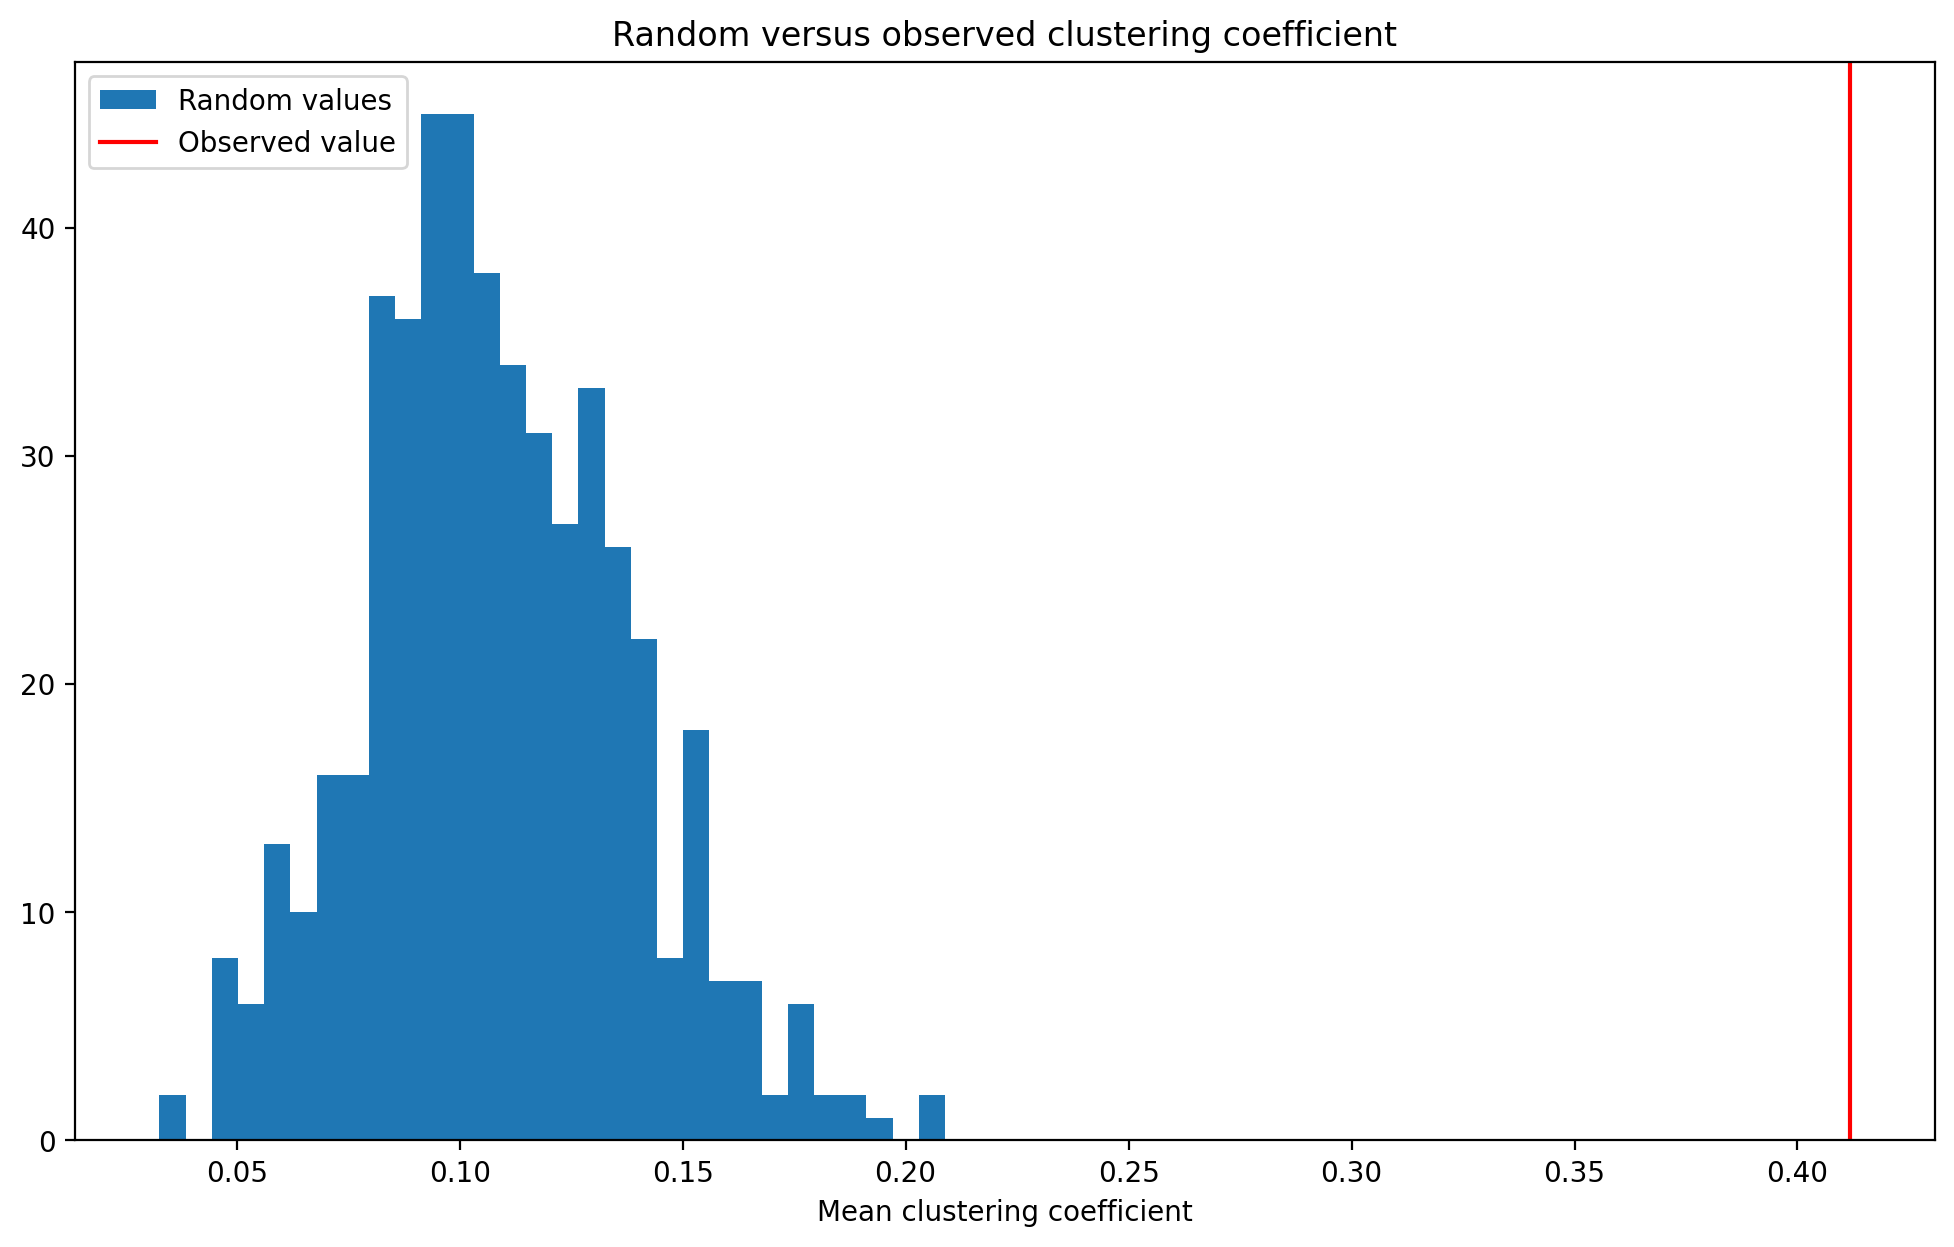

In [47]:
plt.hist(scrambled_results['mean_clustcoeff'], bins=30, label='Random values')
plt.axvline(np.mean(clustcoeff), color='r', label='Observed value')
plt.title('Random versus observed clustering coefficient')
plt.xlabel('Mean clustering coefficient')
plt.legend()

<div class="alert alert-warning">
  <b>ToDo</b> (1 point):<br>
  We previously used a proportional threshold of <code>0.10</code> on the connectome. To assess sensitivity to this choice, compute how the mean clustering coefficient varies across a range of thresholds.
  <ol>
    <li>For each threshold <code>τ</code> in <code>{0.10, 0.15, 0.20, …, 0.50}</code>:
      <ol type="a">
        <li>Apply proportional thresholding to the correlation matrix (keep the top <code>τ</code> fraction of edges; zero the diagonal; enforce symmetry).</li>
        <li>Binarise the thresholded matrix (0/1 adjacency).</li>
        <li>Compute the clustering coefficient for each node and take the mean across nodes.</li>
      </ol>
    </li>
    <li>Store the results in a Pandas DataFrame named <code>clustering_coefficients</code> with exactly two columns:
      <ul>
        <li><code>threshold</code> (float)</li>
        <li><code>mean_clustering_coefficient</code> (float)</li>
      </ul>
    </li>
    <li>Ensure the DataFrame is sorted in ascending order of <code>threshold</code> (starting at <code>0.10</code> and increasing).</li>
  </ol>
  <i>Notes:</i> Reuse the utility functions from above  (e.g., <code>proportional_threshold</code>, <code>binarise_adjacency</code>, <code>clustering_coef_und_binary</code>). Use the same connectome you computed above.
</div>

In [52]:
# YOUR CODE HERE

import numpy as np
import pandas as pd

thresholds = np.arange(0.10, 0.51, 0.05)  

results = []

for tau in thresholds:
    W_thr = proportional_threshold(correlation_matrix, proportion=tau)     # applying proportional thresholding
    A_bin_tau = binarise_adjacency(W_thr)                         # binarising
    C_tau = clustering_coef_und_binary(A_bin_tau)             # clustering coefficients and taking the mean
    mean_C_tau = C_tau.mean()
    results.append({                                          # storing results
        "threshold": float(tau),
        "mean_clustering_coefficient": float(mean_C_tau)
    })

# Pandas dataframe
clustering_coefficients = pd.DataFrame(results)            

# ensure correct sorting ascending by threshold
clustering_coefficients = clustering_coefficients.sort_values(
    by="threshold"
).reset_index(drop=True)

clustering_coefficients

# raise NotImplementedError()

,threshold,mean_clustering_coefficient
0,0.10,0.411864
1,0.15,0.532305
2,0.20,0.517603
3,0.25,0.561061
4,0.30,0.593155
5,0.35,0.598264
6,0.40,0.607805
7,0.45,0.619580
8,0.50,0.634303


In [53]:
# Feedback cell

if "clustering_coefficients" not in locals():
    print('The variable "clustering_coefficients" is not defined. Check that you created and named the variable correctly.')
elif not isinstance(clustering_coefficients, pd.DataFrame):
    print('"clustering_coefficients" should be a Pandas DataFrame.')
elif not np.all(clustering_coefficients.columns == ['threshold', 'mean_clustering_coefficient']):
    print('"clustering_coefficients" should have two columns, with labels "threshold" and "mean_clustering_coefficient"')
elif not clustering_coefficients['mean_clustering_coefficient'].mean() > 0.2:
    print('We expected larger values. Please check your code.')
else:
    print('Your answer passed the automated checks.') 

Your answer passed the automated checks.


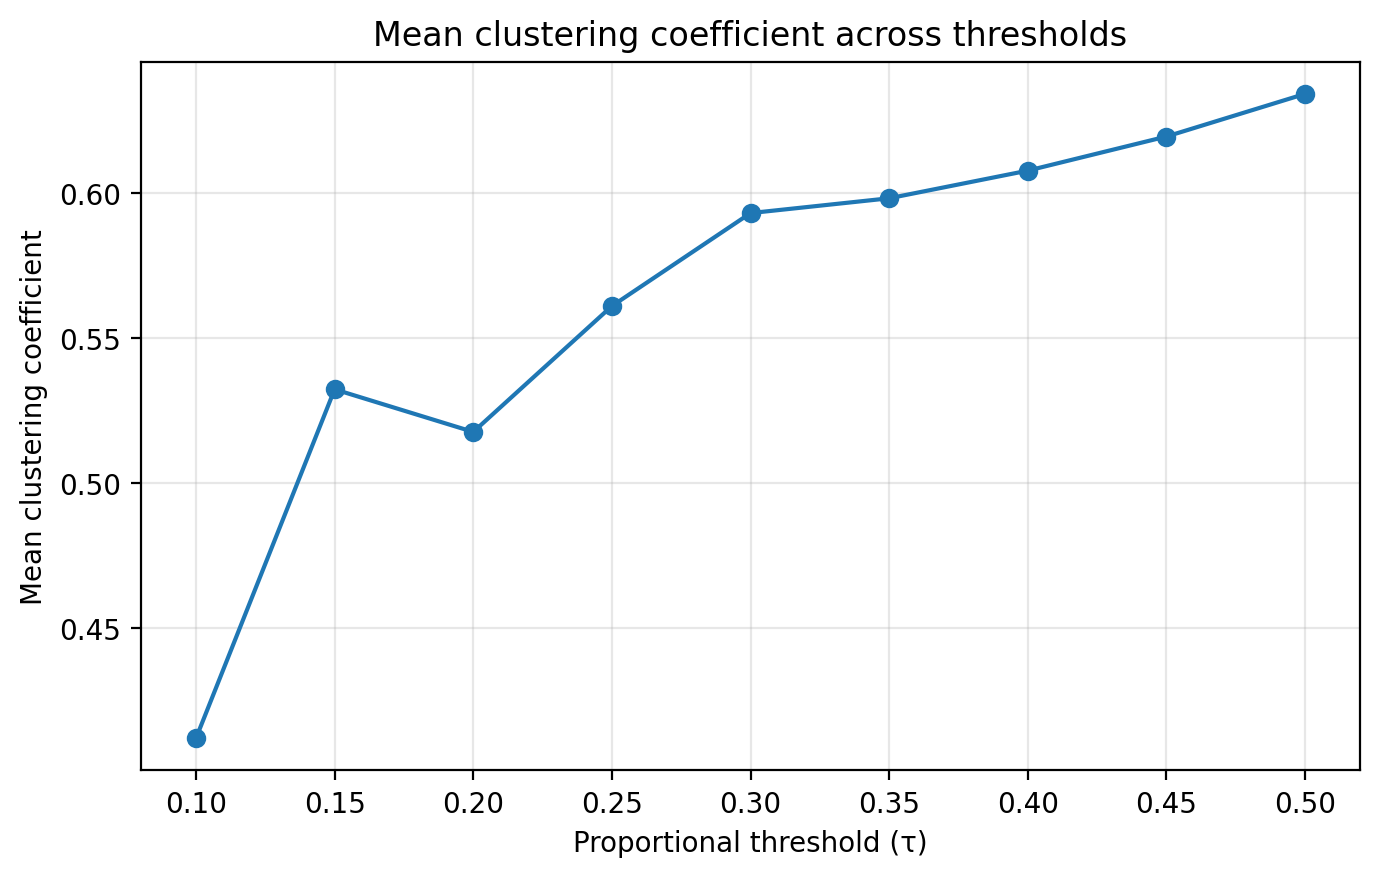

In [54]:
import matplotlib.pyplot as plt

# Line plot of mean clustering coefficient vs proportional threshold
plt.figure(figsize=(7, 4.5))
plt.plot(
    clustering_coefficients["threshold"],
    clustering_coefficients["mean_clustering_coefficient"],
    marker="o"
)
plt.xlabel("Proportional threshold (τ)")
plt.ylabel("Mean clustering coefficient")
plt.title("Mean clustering coefficient across thresholds")
plt.xticks(clustering_coefficients["threshold"].values)  # show all ticks (0.10 → 0.50)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div class="alert alert-info">
  <b>ToThink</b> (0 points):<br>
  Inspect the plot of mean clustering coefficient across proportional thresholds (0.10 → 0.50).  
  What does the shape of this curve tell you about (a) the robustness of your network’s local structure, and (b) the effect of threshold choice on your conclusions?  
  If the curve changes markedly with threshold, how would you report your results to avoid threshold-driven bias?
</div>

<details>
<summary><b>Answer</b></summary>

- **Interpretation of the curve:**  
  - At **low thresholds** (denser graphs), many weak/noisy edges are included, which can **inflate clustering** artificially.  
  - At **high thresholds** (sparser graphs), the network prunes weak links; clustering often **drops** and can become unstable if the graph **fragments**.  

- **Robustness & conclusions:**  
  If your findings (e.g., “network X has higher clustering than network Y”) **only hold at a narrow threshold range**, they may be **threshold-dependent**.

- **Good reporting practice:**  
  - Present results **across thresholds** (the full curve), not just at a single value.  
  - Optionally summarise with an **area-under-the-curve (AUC)** or the **mean across a prespecified range**.  
</details>

## 3. Independent Component Analysis (ICA)

**Independent Component Analysis (ICA)** is a data-driven, model-free method for identifying functional networks in the brain. It relies on the assumption that the observed BOLD signal is a **linear mixture** of a set of statistically independent components.  

In this framework:  
- Each **voxel’s signal** is expressed as a weighted sum of the independent components.  
- The **independent components** are spatial maps that are maximally independent of one another. These maps represent candidate functional networks.  
- The associated **time courses** describe how each component fluctuates over time.  
- Together, the time courses form the **mixing matrix**, and the spatial maps are often referred to as the **source signals**.  

In the following, we will first build intuition for the logic of ICA, and then apply it to functional imaging data.

### 3.1 The Logic Behind ICA

A classic illustration of ICA is the **cocktail party problem**.  
Imagine you are at a busy party, trying to have a conversation while music plays in the background. The sound reaching your ears is a **mixture** of different sources — the voice of the person you are speaking to (the signal of interest) and the background music (unwanted noise).  

The challenge is to **separate the sources** from the mixed signals. ICA provides a mathematical way to do this: it assumes that the observed signals are linear mixtures of statistically independent sources, and it tries to recover those sources.  

The figure below illustrates the cocktail party problem. The microphone symbols represent your two ears, each receiving a different mixture of the voice and the music:  

![Cocktail Party Problem](https://gowrishankar.info/blog/cocktail-party-problem-eigentheory-and-blind-source-separation-using-ica/cocktail-party.png)

To illustrate this, we simulate some data. For easier visualisation, we assume that one signal consists of sine wave and the other of square blocks.

In [55]:
# Simulate source signals (sine and square waves)
np.random.seed(0)
n_samples = 2000
time = np.linspace(0, 8, n_samples)

s1 = np.sin(2 * time)  # Sine wave
s2 = np.sign(np.sin(3 * time))  # Square wave
S = np.c_[s1, s2]

# Mix the signals
A = np.array([[1, 1], [0.5, 2]])  # Mixing matrix
X = S.dot(A.T)

We can apply ICA to this data to separate the two signals. ICA iteratively adjusts the demixing matrix (inverse of the mixing matrix) to maximize the statistical independence of the estimated components.

Here, we use the FastICA algorithm, as implemented in the scikit-learn package.

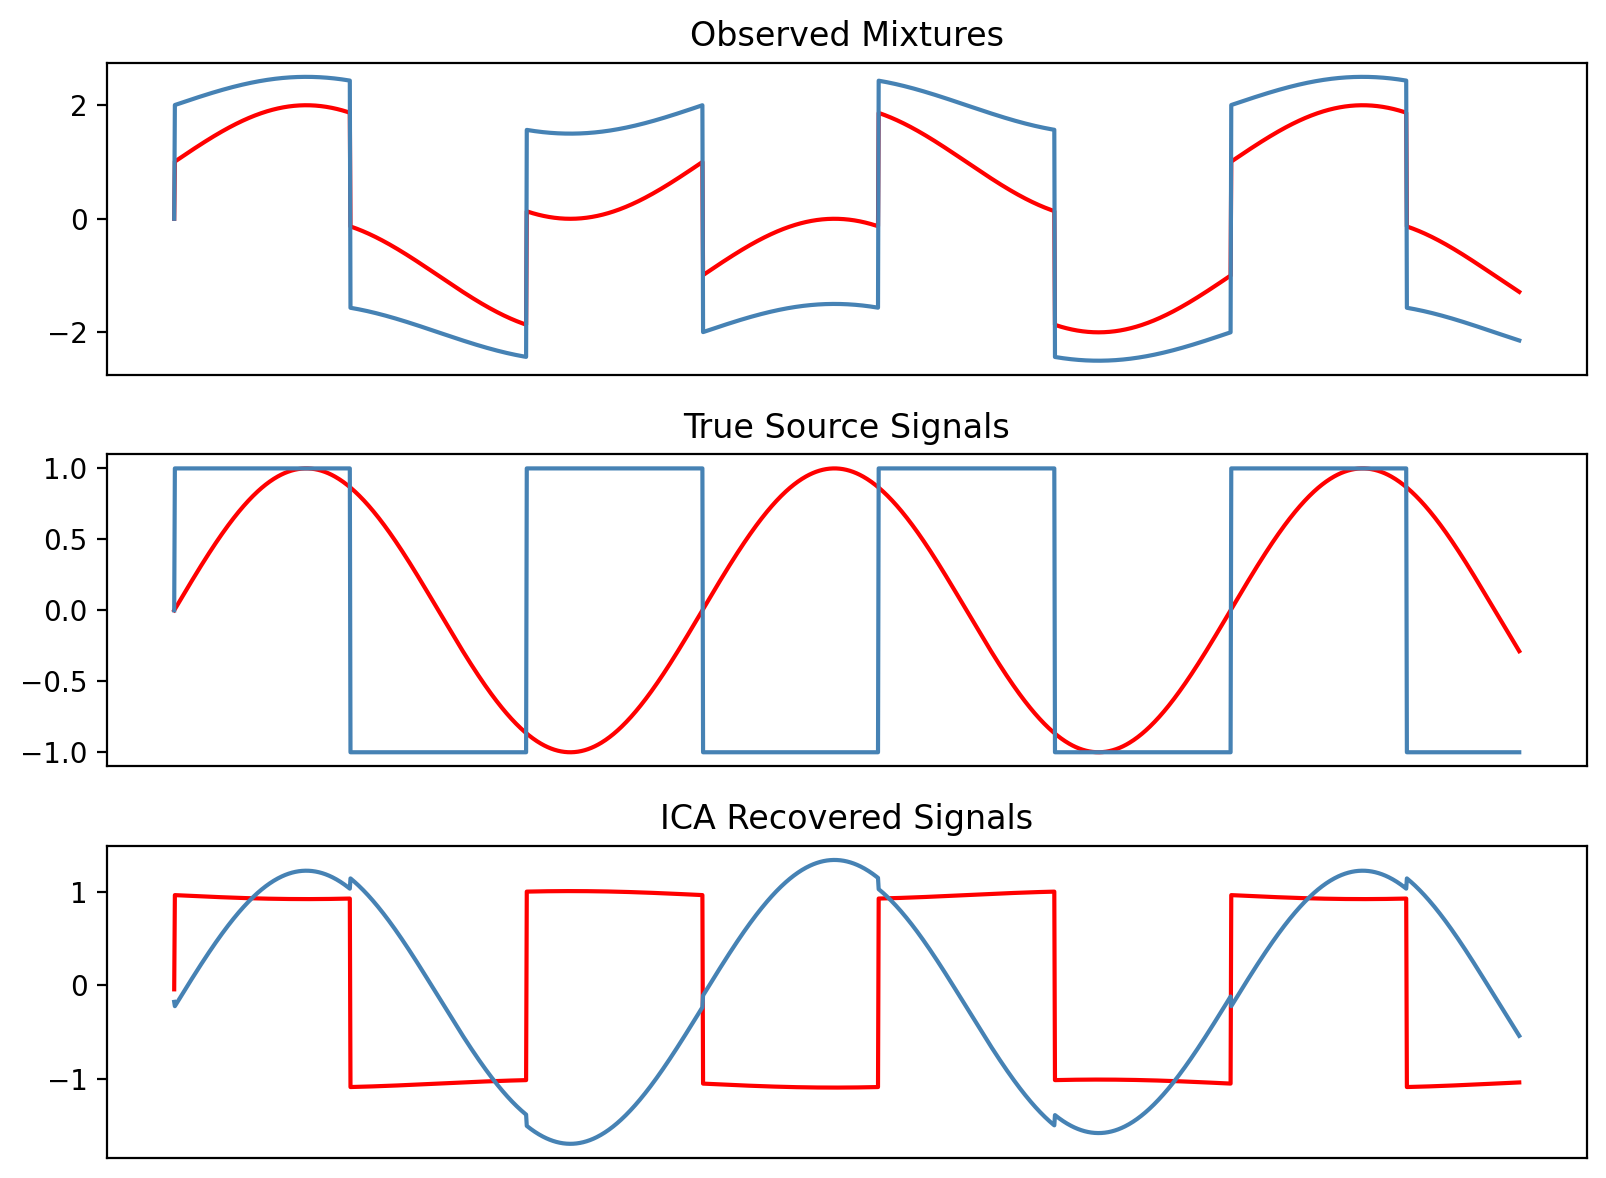

In [56]:
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt

# --- Apply ICA ---
ica = FastICA(n_components=2, random_state=0)
S_est = ica.fit_transform(X)     # Estimated source signals (independent components)
A_est = ica.mixing_              # Estimated mixing matrix

# --- Plot results ---
models = [X, S, S_est]
titles = ["Observed Mixtures", "True Source Signals", "ICA Recovered Signals"]
colors = ["red", "steelblue", "orange"]

plt.figure(figsize=(8, 6))

for i, (signals, title) in enumerate(zip(models, titles), 1):
    plt.subplot(3, 1, i)
    for sig, color in zip(signals.T, colors):
        plt.plot(sig, color=color, lw=1.5)
    plt.title(title)
    plt.xticks([])  # Hide x-axis ticks for clarity

plt.tight_layout()
plt.show()

<div class="alert alert-warning">
  <b>ToDo</b> (2 points):<br>
  As shown in the plot above, ICA does not perfectly recover the original source signals.  
  Your task is to quantify this reconstruction error:  
  <ol>
    <li>Run ICA 100 times with different initialisations.</li>
    <li>For each run, compute the <b>mean squared error (MSE)</b> between the true sources and the recovered signals.</li>
    <li>Because the order of ICA components is arbitrary, compute the MSE for all possible pairings of the two components and keep the <b>lowest</b> value.</li>
    <li>Collect the MSE values across runs, and calculate their mean and standard deviation.</li>
  </ol>
  Store the results in variables named:
  <ul>
    <li><code>mean_mse</code> — the mean of the MSE values across runs</li>
    <li><code>std_mse</code> — the standard deviation of the MSE values across runs</li>
  </ul>
</div>

In [64]:
from sklearn.decomposition import FastICA
import numpy as np

# YOUR CODE HERE
mse_values = []
for _ in range(100):                # running ICA 100 times
    ica = FastICA(n_components=2)
    S_ = ica.fit_transform(X)  # reconstructed signal
    MSEs = []                 # calculating MSEs for each run
    MSEs.append(np.mean((s1 - S_[:, 0]) ** 2))
    MSEs.append(np.mean((s1 - S_[:, 1]) ** 2))
    MSEs.append(np.mean((s2 - S_[:, 0]) ** 2))
    MSEs.append(np.mean((s2 - S_[:, 1]) ** 2))
    mse_values.append(np.min(MSEs))

# mean and SD of MSE
mean_mse = np.mean(mse_values)
std_mse = np.std(mse_values)

# raise NotImplementedError()

print(f"Mean MSE across 100 runs: {mean_mse:.4f}")
print(f"Standard deviation of MSE: {std_mse:.4f}")

Mean MSE across 100 runs: 0.3632
Standard deviation of MSE: 0.6260


In [65]:
# Feedback cell
import nibabel as nib

# Testing Mean MSE
if "mean_mse" not in locals():
    print('The variable "mean_mse" is not defined. Check that you created and named the variable correctly.')
elif not np.isscalar(mean_mse):
    print('"mean_mse" should be a single value')
elif mean_mse <  0.2:
    print('We expected a larger value. Please check your code.')
else:
    print('Your answer passed the automated checks for "mean_mse".')
    
# Testing for STD MSE
if "std_mse" not in locals():
    print('The variable "std_mse" is not defined. Check that you created and named the variable correctly.')
elif not np.isscalar(std_mse):
    print('"std_mse" should be a single value')
elif std_mse < 0.5:
    print('We expected a larger value. Please check your code')
else:
    print('Your answer passed the automated checks for "std_mse".')

Your answer passed the automated checks for "mean_mse".
Your answer passed the automated checks for "std_mse".


In [60]:
assert np.isclose(mean_mse, 0.5, rtol=1e-1) & np.isclose(std_mse, 0.7, rtol=1e-1)

### 3.2 Applying ICA to Functional Imaging Data

Now that we have built some intuition for how ICA works, we can apply it to functional MRI data.  
Compared to seed-based correlation analysis (SCA), ICA generally requires **longer recordings** to obtain stable results — typically at least **10 minutes of data**.  ICA is also quite a computationally demanding method. Therefore, we will not attempt to run this on neuroimaging data on the server. Instead, we'll look a representative result:

![ICA-Maps](https://www.fmrib.ox.ac.uk/datasets/royalsoc8/royalsoc.jpg)

<div class="alert alert-info">
  <b>ToThink</b> (1.5 points):<br>
  Sometimes, ICA components show strong signal in the cerebrospinal fluid (CSF) rather than in grey matter.  
  <ul>
    <li>What does this suggest about the nature of such a component?</li>
    <li>Why is it useful that ICA can identify such components?</li>
    <li>How might you deal with such a component in further analyses?</li>
  </ul>
</div>

1. When ICA components show a strong signal in the CSF rather than in grey matter, this signal is likely noise and not what we're interested in measuring. This may be physiological noise, scanner noise, or motion artifacts. Thus, such ICA components are likely noise components. 
2. It is useful that ICA identifies such components because it isolates potential sources of noise. This is valuable information if we want to ensure our connectivity analyses are valid and reliable. 
3. The standard approach would be to remove this noise\-related ICA component from our analyses. The time series of the CSF ICA component can be regressed out.



In [0]:
# YOUR CODE HERE
raise NotImplementedError()

In [66]:
# Please run this cell to clear up space on the server. 
import os
from shutil import rmtree

if os.path.isdir('./nilearn_cache'):
    rmtree('./nilearn_cache')
    print('Removed nilearn_cache folder')
else:
    print('No nilearn_cache folder found')

Removed nilearn_cache folder


## Conclusion

You might be wondering when to use **seed-based correlation analysis (SCA)**, a **parcellated connectome**, or **ICA**.  
The answer depends on your research question:  

- If your focus is on the connectivity of a *specific region*, **SCA** is most appropriate.  
- If you want to capture the *full connectivity profile* across the brain, a **parcellated connectome** provides a systematic framework.  
- If your goal is to *discover functional networks* in a data-driven way, **ICA** is the method of choice.  

---

### Recap of what we learned in this notebook:
- how to perform **seed-based correlation analysis**  
- how to compute a **parcellated connectome**  
- how to apply basic **graph theory measures** to characterise the connectome  
- how to extract large-scale **functional networks using ICA**  

---

This tutorial only scratches the surface of functional connectivity analysis.  
More advanced approaches include:  
- **dynamic functional connectivity**, which tracks how connections change over time  
- **machine learning methods**, which use connectivity to predict external measures  
- **network science approaches**, offering increasingly sophisticated ways to compare empirical networks with theoretical models  

I hope this notebook has given you a solid starting point for exploring this exciting area of research.  
For a deeper dive, I highly recommend *Fundamentals of Brain Network Analysis* by Fornito, Zalesky, and Bullmore (2016).

## 🎉 Well done!  

Congratulations! You’ve reached the end of this week’s assignment!  